<a href="https://colab.research.google.com/github/mehrerm/TFM/blob/main/notebooks/carga_depuracion_densidadRT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



En esta aplicación implementaremos un modelo de puntuación de riesgo poblacional a la mortalidad debido a los cánceres más comunes y su relación con las cantidades y tecnologías usadas en radioterapia por país.

In [1]:
#Cargo o importo pandas, numpy, Matplotlib,
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import statsmodels.api as sm




import requests
import unicodedata
import os
from pathlib import Path

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, roc_curve

!pip install optbinning
from optbinning import OptimalBinning, Scorecard, BinningProcess
from sklearn.linear_model import LogisticRegression
from urllib.parse import quote




#lugar donde se van guardando las figuras

output_path = Path("TFM/data/processed")
output_path.mkdir(parents=True, exist_ok=True)

fig_dir = "figuras"
os.makedirs(fig_dir, exist_ok=True)

#########################

# Carga, Exploración y Preparación de los datos sobre equipos de radioterapia y pacientes
Se utilizará una base de datos de instalaciones de equipos para radioterapia registrados DIRAC de la IAEA junto con los de la OMS, son datos reales, se buscará el año más actual posible con una cantidad de datos suficientes para hacer el estudio y que tenga lo menos posible la influencia del COVID-19, así como un año anterior a éste.


Los datos de las instalaciones de radioterapia pueden descargarse en la página de la IAEA en el apartado de DIRAC https://dirac.iaea.org/Query/Countries  donde aparecen reflejados los datos de los equipos de radioterapia y el año de sus ultimas actualizaciones a nivel the hardware, por otro lado, se descargaron los datos de la OMS, en el Global Cancer Observatory, donde se descargaron tanto las incidencias como las mortalidades por cáncer y sexo a nivel mundial https://gco.iarc.fr/overtime/en/dataviz/trends?populations=752&sexes=1_2&types=1&multiple_populations=1.
Asimismo, se descargó la información demográfica encontrada en la ONU en el apartado "United Nations World Population Prospects (WPP) para poder ver la densidad poblacional.
Por otro lado, también se ha visto que es necesario para entender mejor la calidad de vida y sobreviviencia, que el PIB per capita puede jugar un papel importante, por lo tanto, también se sumará ese valor a los paises a estudiar, en ese caso se usará una url directa que da los datos sin necesidad de guardarlos en el repositorio que se tiene para tal fin.

## Carga de datos

In [2]:
# Cargamos los datos

# URL base del repositorio
url_base = "https://raw.githubusercontent.com/mehrerm/TFM/main/data/raw/"

#DIRAC
#Datos de los equipos y centros de radioterapia por país

#url_dirac = (
 #   url_base + "DIRAC_Countries.xlsx"
#)

#WHO datos de densidad de equipos de RT por años

url_dirac = url_base + "RT_densidad_anio.csv"
dirac = pd.read_csv(url_dirac)
print(["Para DIRAC se tiene:"])
print(dirac.head(5))

#GLOBOCAN
#datos de tipos de cancer más tratados con radioterapia, incidencia, mortalidad
#por año
# Archivos
files_cancer = {
    "lung": "dataset-asr-inc-and-mort-males-and-females-lung.csv",
    "breast": "dataset-asr-inc-and-mort-males-and-females-breast.csv",
    "prostate": "dataset-asr-inc-and-mort-males-and-females-prostat.csv",
    #"colon": "dataset-asr-inc-and-mort-males-and-females-colon.csv",
    "cervix": "dataset-asr-inc-and-mort-males-and-females-cervix-uterino.csv",
}

# Carga de datasets
dfd_cancer = []
print(["Para GLOBOCAN se tiene:"])
for cancer, filename in files_cancer.items():
    url = url_base + quote(filename)
    df_cancer = pd.read_csv(url)



    dfd_cancer.append(df_cancer)

    print(f"{cancer.upper():10s} -> shape: {df_cancer.shape}")

df_all_cancer = pd.concat(dfd_cancer, ignore_index=True)


#ONU
#Población mundial acorde con los datos de la ONU

url_pop = (
       url_base + "WPP2024_TotalPopulationBySex.csv.gz"
)


pop = pd.read_csv(url_pop, compression='gzip')
print(["Para la ONU se tiene:"])
print(pop.head(5))


# Banco mundial para estudiar los pib per capita
url_BM = (
    "https://api.worldbank.org/v2/country/all/indicator/NY.GDP.PCAP.CD"
    "?format=json&per_page=20000"
)



PIB_ = requests.get(url_BM).json()

df_PIB_raw = pd.DataFrame(PIB_[1])

df_PIB = df_PIB_raw[["countryiso3code", "country", "date", "value", "indicator"]].copy()
print(["Para el banco mundial se tiene"])
print(df_PIB.head(5))




['Para DIRAC se tiene:']
  IndicatorCode                                          Indicator ValueType  \
0     DEVICES22  Total density per million population: Radiothe...      text   
1     DEVICES22  Total density per million population: Radiothe...      text   
2     DEVICES22  Total density per million population: Radiothe...      text   
3     DEVICES22  Total density per million population: Radiothe...      text   
4     DEVICES22  Total density per million population: Radiothe...      text   

  ParentLocationCode   ParentLocation Location type SpatialDimValueCode  \
0                AFR           Africa       Country                 BFA   
1                AFR           Africa       Country                 COM   
2                WPR  Western Pacific       Country                 FSM   
3                AFR           Africa       Country                 ETH   
4                AFR           Africa       Country                 UGA   

                           Location Period 

/tmp/ipython-input-909952770.py:56: DtypeWarning: Columns (2,3,4,7) have mixed types. Specify dtype option on import or set low_memory=False.
  pop = pd.read_csv(url_pop, compression='gzip')


['Para la ONU se tiene:']
   SortOrder  LocID Notes ISO3_code ISO2_code  SDMX_code  LocTypeID  \
0        NaN   5507   NaN       NaN       NaN        NaN        NaN   
1        NaN   5507   NaN       NaN       NaN        NaN        NaN   
2        NaN   5507   NaN       NaN       NaN        NaN        NaN   
3        NaN   5507   NaN       NaN       NaN        NaN        NaN   
4        NaN   5507   NaN       NaN       NaN        NaN        NaN   

  LocTypeName  ParentID                           Location  VarID Variant  \
0         NaN       NaN  ADB region: Central and West Asia      2  Medium   
1         NaN       NaN  ADB region: Central and West Asia      2  Medium   
2         NaN       NaN  ADB region: Central and West Asia      2  Medium   
3         NaN       NaN  ADB region: Central and West Asia      2  Medium   
4         NaN       NaN  ADB region: Central and West Asia      2  Medium   

   Time  MidPeriod    PopMale  PopFemale   PopTotal  PopDensity  
0  1950     1950.5

## Descripción inicial de los datos

## Depuración y exploración de los datos

### ONU
Con esta dataset, se pretende conseguir la población global por año

In [3]:
print(pop.head())
print(pop["LocTypeName"].unique())

   SortOrder  LocID Notes ISO3_code ISO2_code  SDMX_code  LocTypeID  \
0        NaN   5507   NaN       NaN       NaN        NaN        NaN   
1        NaN   5507   NaN       NaN       NaN        NaN        NaN   
2        NaN   5507   NaN       NaN       NaN        NaN        NaN   
3        NaN   5507   NaN       NaN       NaN        NaN        NaN   
4        NaN   5507   NaN       NaN       NaN        NaN        NaN   

  LocTypeName  ParentID                           Location  VarID Variant  \
0         NaN       NaN  ADB region: Central and West Asia      2  Medium   
1         NaN       NaN  ADB region: Central and West Asia      2  Medium   
2         NaN       NaN  ADB region: Central and West Asia      2  Medium   
3         NaN       NaN  ADB region: Central and West Asia      2  Medium   
4         NaN       NaN  ADB region: Central and West Asia      2  Medium   

   Time  MidPeriod    PopMale  PopFemale   PopTotal  PopDensity  
0  1950     1950.5  35880.164  33333.260  69

In [4]:
# En LocTypeName, filtrar: países, escenario Medium
ONU_c = pop[
    (pop["LocTypeName"] == "Country/Area") &
    (pop["Variant"] == "Medium")
    #El escenario es Medium porque es el escenario más estandarizado
    #esto se debe a que también presenta datos extrapolados sergún distintos
    #criterios
   # (pop["Time"].isin([2016, 2022]))

].copy()

# Seleccionar y renombrar columnas
ONU_c = (
    ONU_c[["Location", "Time", "PopTotal", "PopMale","PopFemale"]]
    .rename(columns={
    "Location": "Country_harmonized",
    "Time": "Year",
    "PopTotal": "Population",
    "PopMale": "Population_male",
    "PopFemale": "Population_female"
})
)

# Convertir tipos
ONU_c["Year"] = ONU_c["Year"].astype(int)

# PopTotal está en miles, pasar a personas
cols = ["Population", "Population_male", "Population_female"]
ONU_c[cols] = ONU_c[cols] * 1000

# Comprobaciones rápidas
print(ONU_c.shape)
print(ONU_c.head(5))

# Guardar CSV reducido
ONU_c.to_csv(
    "population_UN_WPP2024.csv",
    index=False
)

print(ONU_c["Country_harmonized"].unique())
ONU_c["Year"].unique()

(35787, 5)
       Country_harmonized  Year  Population  Population_male  \
336230            Burundi  1950   2254938.0        1080184.0   
336231            Burundi  1951   2305746.0        1105816.0   
336232            Burundi  1952   2355804.0        1130995.0   
336233            Burundi  1953   2405186.0        1155833.0   
336234            Burundi  1954   2454586.0        1180690.0   

        Population_female  
336230          1174755.0  
336231          1199930.0  
336232          1224809.0  
336233          1249353.0  
336234          1273896.0  
['Burundi' 'Comoros' 'Djibouti' 'Eritrea' 'Ethiopia' 'Kenya' 'Madagascar'
 'Malawi' 'Mauritius' 'Mayotte' 'Mozambique' 'Réunion' 'Rwanda'
 'Seychelles' 'Somalia' 'South Sudan' 'Uganda'
 'United Republic of Tanzania' 'Zambia' 'Zimbabwe' 'Angola' 'Cameroon'
 'Central African Republic' 'Chad' 'Congo'
 'Democratic Republic of the Congo' 'Equatorial Guinea' 'Gabon'
 'Sao Tome and Principe' 'Algeria' 'Egypt' 'Libya' 'Morocco' 'Sudan'
 'Tu

array([1950, 1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959, 1960,
       1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971,
       1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982,
       1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993,
       1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004,
       2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015,
       2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026,
       2027, 2028, 2029, 2030, 2031, 2032, 2033, 2034, 2035, 2036, 2037,
       2038, 2039, 2040, 2041, 2042, 2043, 2044, 2045, 2046, 2047, 2048,
       2049, 2050, 2051, 2052, 2053, 2054, 2055, 2056, 2057, 2058, 2059,
       2060, 2061, 2062, 2063, 2064, 2065, 2066, 2067, 2068, 2069, 2070,
       2071, 2072, 2073, 2074, 2075, 2076, 2077, 2078, 2079, 2080, 2081,
       2082, 2083, 2084, 2085, 2086, 2087, 2088, 2089, 2090, 2091, 2092,
       2093, 2094, 2095, 2096, 2097, 2098, 2099, 21

In [5]:
#nombres de paises, se estandarizarán los nombres de los paises de todos los
#dataset

country_mapping = {

    "Macau, China": "Macao",
    "Taiwan, China": "Taiwan",
    'China, Hong Kong SAR': "Hong Kong",
    "China, Macao SAR": "Macao",
    'China, Taiwan Province of China': "Taiwan",
    'China, Republic of China': "China",
    "Macao SAR, China": "Macao",

    'Lao PDR': "Lao",
    "Lao People's Democratic Republic": "Lao",



    'Czech Republic': 'Czechia',

    "Slovak Republic": "Slovakia",

    "United Kingdom of Great Britain and Northern Ireland": "United Kingdom",

    "UK, England": "United Kingdom",
    "UK, Wales": "United Kingdom",
    "UK, Scotland": "United Kingdom",
    "UK, Northern Ireland": "United Kingdom",
    "UK, England and wales": "United Kingdom",


    "France (metropolitan)": "France",
    "France, Martinique": "Martinique",

    "USA": "United States of America",
    "United States" : "United States of America",
    "United States of America (the)": "United States of America",

    "Puerto Rico (US)": "Puerto Rico",



    "Korea, Republic of": "South Korea",
    "Republic of Korea" : "South Korea",
    "Korea, Rep.": "South Korea",
    "Korea, Democratic People's Republic of": "North Korea",


    "Iran, Islamic Republic of": "Iran",
    "Iran (Islamic Republic of)": "Iran",

    "Viet Nam": "Vietnam",

    'Venezuela, Bolivarian Republic of': 'Venezuela',
    'Venezuela (Bolivarian Republic of)': 'Venezuela',
    "Venezuela, RB": "Venezuela",

    'Bolivia, Plurinational State of': 'Bolivia',
    'Bolivia (Plurinational State of)': 'Bolivia',

    "Netherlands, Kingdom of the": "The Netherlands",

    "Republic of Moldova": "Moldova", # Comma added here

    "Kyrgyz Republic": "Kyrgyzstan",

    "Syrian Arab Republic": "Syria"

}

En la celda anterior presenta una lista de países cuyos nombres se han cambiado para que coincidan los 4 datasets.

In [6]:
# se limpian los caracteres de los paises y se cambian los nombres de aquellos
#que sean necesarios


ONU_c["Country_harmonized"] = ONU_c["Country_harmonized"].replace(country_mapping)

ONU_c["Country_harmonized"] = ONU_c["Country_harmonized"].apply(
    lambda x: unicodedata.normalize("NFKD", x)
        .encode("ASCII", "ignore")
        .decode("utf-8") if pd.notna(x) else x
)

print(ONU_c['Country_harmonized'].unique())
print(ONU_c.info())
print(ONU_c.isna().sum().sum())
print(ONU_c['Year'].unique())


['Burundi' 'Comoros' 'Djibouti' 'Eritrea' 'Ethiopia' 'Kenya' 'Madagascar'
 'Malawi' 'Mauritius' 'Mayotte' 'Mozambique' 'Reunion' 'Rwanda'
 'Seychelles' 'Somalia' 'South Sudan' 'Uganda'
 'United Republic of Tanzania' 'Zambia' 'Zimbabwe' 'Angola' 'Cameroon'
 'Central African Republic' 'Chad' 'Congo'
 'Democratic Republic of the Congo' 'Equatorial Guinea' 'Gabon'
 'Sao Tome and Principe' 'Algeria' 'Egypt' 'Libya' 'Morocco' 'Sudan'
 'Tunisia' 'Western Sahara' 'Botswana' 'Eswatini' 'Lesotho' 'Namibia'
 'South Africa' 'Benin' 'Burkina Faso' 'Cabo Verde' "Cote d'Ivoire"
 'Gambia' 'Ghana' 'Guinea' 'Guinea-Bissau' 'Liberia' 'Mali' 'Mauritania'
 'Niger' 'Nigeria' 'Saint Helena' 'Senegal' 'Sierra Leone' 'Togo'
 'Kazakhstan' 'Kyrgyzstan' 'Tajikistan' 'Turkmenistan' 'Uzbekistan'
 'China' 'Hong Kong' 'Macao' 'Taiwan' "Dem. People's Republic of Korea"
 'Japan' 'Mongolia' 'South Korea' 'Afghanistan' 'Bangladesh' 'Bhutan'
 'India' 'Iran' 'Maldives' 'Nepal' 'Pakistan' 'Sri Lanka'
 'Brunei Darussalam' 'C

Variables a utilizar:

* Country_harmonized: los países con información

* Year: año

* Population: población tanto hombres como mujeres

* Population_male: pobración de hombres

* Population_female: población de mujeres

Los datos de población utilizados en este estudio proceden de la base World Population Prospects 2024 elaborada por la División de Población del Departamento de Asuntos Económicos y Sociales de las Naciones Unidas (ONU). Según la metodología oficial de esta fuente, las estimaciones de población se basan en datos observados provenientes de censos nacionales, registros vitales y encuestas demográficas, mientras que las proyecciones de población comienzan a partir del año 2024.

Aunque el conjunto de datos incluye estimaciones hasta el año 2023, la disponibilidad y calidad de los datos demográficos recientes varía considerablemente entre países. En muchos casos, los últimos censos o registros vitales utilizados como base empírica corresponden a años anteriores, especialmente en el periodo posterior a la pandemia de COVID-19. Como consecuencia, los valores más recientes incorporan un mayor grado de interpolación y ajuste modelizado.

Por este motivo, y con el objetivo de evitar el uso de datos proyectados o altamente modelizados, y debido a las exploraciones posteriores con el resto de nuestras fuentes de datos, en este trabajo se selecciona el año 2022 como el año más reciente con una cobertura amplia y consistente de datos poblacionales basados mayoritariamente en información observada (y no extrapolada).

La utilización del año 2022 resulta, además, especialmente adecuada para su integración con los datos de mortalidad por cáncer de GLOBOCAN y los datos de infraestructura de radioterapia del registro DIRAC, que presentan una mayor disponibilidad y estabilidad en torno a ese periodo temporal. De este modo, la fusión de las fuentes se realiza minimizando sesgos del uso de proyecciones demográficas.

Asimismo, se utilizará el año 2016, ya que es un año también bastante consistente donde además, en GLOBOCAN, presenta buena recolección de datos sobre incidencias, algo que más adelante se demostrará que años posteriores, este valor estará ausente a la mayoría de países.


#WHO

En este base de datos tenemos todo lo referente a las unidades de radioterapia, las cuales son los aceleradores lineales y los equipos emisores gamma de cobalto. Su densidad segun población en el momento del registro, a lo largo de distintos años: '2021', '2017-2021', '2014', '2013', '2010'. Esto nos puede ayudar a entender si efectivamente el indice de mortalidad disminuye si aumentamos la densidad de estos equipos a lo largo del tiempo, este dato es importante ya que para ver efectivamente los efectos de un tratamiento, hay que ver al menos 5 años tras el registro del mismo. Por lo tanto, se buscará la correlación de equipos en un determinado año (2010, por ejemplo) y la mortalidad durante los 5 años posteriores (2015).

In [7]:
dirac.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 481 entries, 0 to 480
Data columns (total 34 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   IndicatorCode               481 non-null    object 
 1   Indicator                   481 non-null    object 
 2   ValueType                   481 non-null    object 
 3   ParentLocationCode          481 non-null    object 
 4   ParentLocation              481 non-null    object 
 5   Location type               481 non-null    object 
 6   SpatialDimValueCode         481 non-null    object 
 7   Location                    481 non-null    object 
 8   Period type                 481 non-null    object 
 9   Period                      481 non-null    object 
 10  IsLatestYear                481 non-null    bool   
 11  Dim1 type                   0 non-null      float64
 12  Dim1                        0 non-null      float64
 13  Dim1ValueCode               0 non-n

In [8]:
dirac["Period"].unique()

array(['2021', '2017-2021', '2014', '2013', '2010'], dtype=object)

In [9]:
# List the columns you want to drop
columns_to_drop = [
    'IndicatorCode',
    'ValueType',
    'ParentLocationCode',
    'Location type',
    'SpatialDimValueCode',
    'Period type',
    'IsLatestYear',
    'Dim1 type',
    'Dim1',
    'Dim1ValueCode',
    'Dim2 type',
    'Dim2',
    'Dim2ValueCode',
    'Dim3 type',
    'Dim3',
    'Dim3ValueCode',
    'DataSourceDimValueCode',
    'DataSource',
    'FactValueNumeric',
    'FactValueNumericPrefix',
    'FactValueUoM',
    'FactValueNumericLowPrefix',
    'FactValueNumericLow',
    'FactValueNumericHighPrefix',
    'FactValueNumericHigh',
    'FactValueTranslationID',
    'Language',
    'DateModified',
    'FactComments'
]

# Drop the columns from the DataFrame (e.g., dirac)
# I will use 'dirac' as it was the last dataframe being processed before the current context.
# If you want to drop columns from a different dataframe, replace 'dirac' with its name.
# The 'errors="ignore"' argument prevents an error if a column in the list doesn't exist.
dirac = dirac.drop(columns=columns_to_drop, errors="ignore")

# Display the columns after dropping to verify
print(dirac.head())


                                           Indicator   ParentLocation  \
0  Total density per million population: Radiothe...           Africa   
1  Total density per million population: Radiothe...           Africa   
2  Total density per million population: Radiothe...  Western Pacific   
3  Total density per million population: Radiothe...           Africa   
4  Total density per million population: Radiothe...           Africa   

                           Location Period  Value  
0                      Burkina Faso   2021   0.00  
1                           Comoros   2021   0.00  
2  Micronesia (Federated States of)   2021   0.00  
3                          Ethiopia   2021   0.09  
4                            Uganda   2021   0.09  


In [10]:
dirac_melted = dirac.copy()

# Rename columns to desired names
dirac = dirac.rename(columns={
    "Location": "Country_harmonized",
    "ParentLocation": "Region Name",
    "Total density per million population: Radiotherapy units": "RTUnit",
    "Period" : "Year_Units",
    "Value" : "RT_m"
})





In [11]:
dirac["Country_harmonized"] = dirac["Country_harmonized"].replace(country_mapping)

dirac["Country_harmonized"] = dirac["Country_harmonized"].apply(
    lambda x: unicodedata.normalize("NFKD", x)
        .encode("ASCII", "ignore")
        .decode("utf-8") if pd.notna(x) else x
)

# Replace '2017-2021' with '2017' in Year_Units column
dirac['Year_Units'] = dirac['Year_Units'].replace('2017-2021', '2017')
# Convert 'Year_Units' + 5 years
dirac['Year_Units'] = dirac['Year_Units'].astype(int)
dirac["Year"] = dirac["Year_Units"] + 5
print(dirac['Country_harmonized'].unique())
print(dirac.info())
print(dirac.isna().sum().sum())
print(dirac['Year'].unique())


['Burkina Faso' 'Comoros' 'Micronesia (Federated States of)' 'Ethiopia'
 'Uganda' 'Senegal' 'Jordan' 'Finland' 'Lithuania' 'Luxembourg'
 'Mozambique' 'Yemen' 'Cameroon' 'Nigeria' 'Mali' 'Madagascar'
 "Cote d'Ivoire" 'Angola' 'Rwanda' 'United Republic of Tanzania'
 'Cambodia' 'Tajikistan' 'Bangladesh' 'Ghana' 'Lao' 'Sudan' 'Uzbekistan'
 'Zambia' 'Indonesia' 'Kenya' 'Pakistan' 'Nepal' 'Kyrgyzstan' 'Iraq'
 'Vietnam' 'Myanmar' 'Oman' 'Philippines' 'Mauritania' 'Zimbabwe' 'Syria'
 'India' 'United Arab Emirates' 'Guatemala' 'Gabon' 'Honduras' 'Nicaragua'
 'Moldova' 'Sri Lanka' 'Bolivia' 'Algeria' 'Libya' 'Azerbaijan' 'Bahrain'
 'Namibia' 'Saudi Arabia' 'China' 'Botswana' 'Costa Rica' 'Qatar' 'Egypt'
 'Kuwait' 'Morocco' 'Paraguay' 'Ecuador' 'Iran' 'Armenia' 'El Salvador'
 'Turkmenistan' 'Mongolia' 'Mexico' 'Netherlands (Kingdom of the)' 'Japan'
 'Norway' 'Antigua and Barbuda' 'Czechia' 'Germany' 'Belgium' 'Ireland'
 'Denmark' 'Switzerland' 'Sweden' 'United States of America' 'Thailand'
 'Alba

In [12]:
dirac[dirac.isna().any(axis=1)]


,Indicator,Region Name,Country_harmonized,Year_Units,RT_m,Year


In [13]:
dirac.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 481 entries, 0 to 480
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Indicator           481 non-null    object 
 1   Region Name         481 non-null    object 
 2   Country_harmonized  481 non-null    object 
 3   Year_Units          481 non-null    int64  
 4   RT_m                481 non-null    float64
 5   Year                481 non-null    int64  
dtypes: float64(1), int64(2), object(3)
memory usage: 22.7+ KB


##Variables encontradas
Entonces, con estos datos se tiene lo siguiente:

* 'Country_harmonized' = país al que corresponde la información

* 'Region Name' = región geográfica o continental en la que se localiza el país.

* 'RTCenters' = número de centros que disponen de al menos un equipo de radioterapia.

* 'Linacs' = número de centros con equipos de teleterapia que utilizan haces de fotones y electrones.

* 'Protontherapy'= número de centros con disponibilidad de protonterapia.

* 'XRay' = número de generadores de rayos X utilizados con fines terapéuticos.

* 'Brachytherapy' = número de equipos de braquiterapia, incluyendo tanto fuentes radiactivas como sistemas de braquiterapia electrónica mediante generadores miniaturizados de rayos X.

* 'Last Update' = año de la última actualización de la información registrada para cada país.

Las variables pueden clasificarse en cualitativas nominales, cuantitativas discretas y una variable temporal, lo que permite realizar posteriormente un análisis exploratorio orientado a la detección de valores atípicos (outliers) y a la normalización por población.

Ahora se realiza un análisis exploratorio para buscar outliers, si es que los hay.




In [14]:
categ_vars = dirac.select_dtypes(include='object').columns


In [15]:
#explotar las variables categoricas

for col in categ_vars:
    print(f"Valores únicos en {col}:")
    print(dirac[col].unique())
    print("-" * 40)

Valores únicos en Indicator:
['Total density per million population: Radiotherapy units']
----------------------------------------
Valores únicos en Region Name:
['Africa' 'Western Pacific' 'Eastern Mediterranean' 'Europe'
 'South-East Asia' 'Americas']
----------------------------------------
Valores únicos en Country_harmonized:
['Burkina Faso' 'Comoros' 'Micronesia (Federated States of)' 'Ethiopia'
 'Uganda' 'Senegal' 'Jordan' 'Finland' 'Lithuania' 'Luxembourg'
 'Mozambique' 'Yemen' 'Cameroon' 'Nigeria' 'Mali' 'Madagascar'
 "Cote d'Ivoire" 'Angola' 'Rwanda' 'United Republic of Tanzania'
 'Cambodia' 'Tajikistan' 'Bangladesh' 'Ghana' 'Lao' 'Sudan' 'Uzbekistan'
 'Zambia' 'Indonesia' 'Kenya' 'Pakistan' 'Nepal' 'Kyrgyzstan' 'Iraq'
 'Vietnam' 'Myanmar' 'Oman' 'Philippines' 'Mauritania' 'Zimbabwe' 'Syria'
 'India' 'United Arab Emirates' 'Guatemala' 'Gabon' 'Honduras' 'Nicaragua'
 'Moldova' 'Sri Lanka' 'Bolivia' 'Algeria' 'Libya' 'Azerbaijan' 'Bahrain'
 'Namibia' 'Saudi Arabia' 'China' 'Bot

Con esto se demuestra que estos valores anómalos están en la última fila por consecuencia de sumar todos los equipos y centros y calcular la última actualización, entonces, esta fila se eliminará de los datos. Otra operación que sería interesante modificar son los nombres con caracteres que nos podría dar problemas, así como asegurarse de que no hay paises repetidos.

Debido a que hay países que están segregados por zonas, se unificarán usando Country_harmonized.

Durante el proceso de armonización geográfica se identificaron territorios no soberanos, como Martinica, que inicialmente se consideraron candidatos a ser integrados bajo el Estado correspondiente (Francia). No obstante, un análisis exploratorio de los datos epidemiológicos reveló diferencias sustanciales entre Francia y Martinica en las variables clave de GLOBOCAN, tales como la tasa estandarizada por edad (ASR World), la tasa bruta, el riesgo acumulado y el número total de casos. Por lo tanto, se usarán por separado, algo que no ocurre con UK, donde todo el territorio tiene resultados estadísticos similares, donde entonces si se sumarán casos y se promediarán los datos numeros como el ASR que son tasas.

Adicionalmente, se constató que ambas fuentes de datos GLOBOCAN y DIRAC, proporcionan información diferenciada para Martinica y Francia. En consecuencia, y con el fin de preservar la coherencia interna de los datos y evitar la introducción de sesgos derivados de agregaciones no justificadas, se decidió mantener Martinica como una entidad separada en el análisis.


In [16]:
# Comprobar duplicados por país y Year_Units
n_dups = dirac.duplicated(subset=["Country_harmonized", "Year_Units"]).sum()

print(f"Number of duplicates after cleaning: {n_dups}")


Number of duplicates after cleaning: 0


Dado que el único campo no numérico del conjunto DIRAC corresponde al año de la última actualización, no fue necesario aplicar reglas de agregación adicionales para variables categóricas.

In [17]:
dirac_clean = dirac.copy()


In [18]:
dirac_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 481 entries, 0 to 480
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Indicator           481 non-null    object 
 1   Region Name         481 non-null    object 
 2   Country_harmonized  481 non-null    object 
 3   Year_Units          481 non-null    int64  
 4   RT_m                481 non-null    float64
 5   Year                481 non-null    int64  
dtypes: float64(1), int64(2), object(3)
memory usage: 22.7+ KB


Se ha limpiado de caracteres anómalos en países.
Con los datos numéricos entonces, se analiza si existe algun dato anomalo

Con estos resultados, se puede saber que hay paises con valores extremos y otros donde escasamente hay un solo equipo. Se puede ver que hay paises donde es cero en equipos mientras que otros tienen hasta 2237 centros con radioterapia, esto tiene sentido si se explora que paises son así como su población, esto se hará más adelante con los datos del BM.


Con estos resultados es necesario tener entonces los datos demograficos por país, ademas de los datos de cancer.
Ahora, a explorar y depurar los datos provenientes de
#GLOBOCAN.
En donde se podrá encontrar los indice de incidencia y mortalidad segun sexo, tipo de cancer, pais y año.
Para esto, se ha tomado seis tipos de cancer muy comunes: Pulmon, mama, prostata, colon, cervix y leucemia.

In [19]:

df_all_cancer["Cancer label"].unique()


array(['Lung', 'Breast', 'Prostate', 'Cervix uteri'], dtype=object)

In [20]:
#se cambia solamente el nombre de Cervix uteri
df_all_cancer["Cancer label"] = df_all_cancer["Cancer label"].replace(
    {"Cervix uteri": "Cervix"}
)


In [21]:
df_all_cancer["Cancer label"].unique()

array(['Lung', 'Breast', 'Prostate', 'Cervix'], dtype=object)

In [22]:
df_all_cancer["Cancer label"].value_counts()

,count
Cancer label,
Lung,3280
Breast,1640
Prostate,1640
Cervix,1640


In [23]:
df_all_cancer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8200 entries, 0 to 8199
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Cancer id        8200 non-null   int64  
 1   Cancer label     8200 non-null   object 
 2   Population id    8200 non-null   int64  
 3   Country label    8200 non-null   object 
 4   Sex              8200 non-null   int64  
 5   Type             8200 non-null   int64  
 6   Year             8200 non-null   int64  
 7   ASR (World)      8200 non-null   float64
 8   Crude rate       8200 non-null   float64
 9   Cumulative risk  8200 non-null   float64
 10  Total            8200 non-null   int64  
dtypes: float64(3), int64(6), object(2)
memory usage: 704.8+ KB


Se puede observar que para un cáncer como el que afecta exclusivamente un sexo de la población , los datos son la mitad (1640 filas) del resto donde se toma en cuenta ambos sexos (3280 filas). En el caso de Estados Unidos, GLOBOCAN proporciona información adicional desagregada por grupos poblacionales (p. ej., “USA: White” y “USA: Black”), además de los datos correspondientes al total nacional. Dado que estas categorías no representan unidades geográficas independientes y que el conjunto de datos incluye la población total, dichas desagregaciones se excluyeron del análisis para evitar duplicidades y distorsiones en los indicadores epidemiológicos.

Los distintos conjuntos de datos correspondientes a cada tipo de cáncer se integraron en un único dataframe, incorporando una variable identificadora del tipo de cáncer para facilitar el análisis conjunto.


In [24]:
df_all_cancer = df_all_cancer.drop(columns=["Cancer id", "Population id"], errors="ignore")




In [25]:

print(df_all_cancer.info())


for col in df_all_cancer:
    print(f"\n {col}")
    print(df_all_cancer[col].unique())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8200 entries, 0 to 8199
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Cancer label     8200 non-null   object 
 1   Country label    8200 non-null   object 
 2   Sex              8200 non-null   int64  
 3   Type             8200 non-null   int64  
 4   Year             8200 non-null   int64  
 5   ASR (World)      8200 non-null   float64
 6   Crude rate       8200 non-null   float64
 7   Cumulative risk  8200 non-null   float64
 8   Total            8200 non-null   int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 576.7+ KB
None

 Cancer label
['Lung' 'Breast' 'Prostate' 'Cervix']

 Country label
['Belarus' 'Canada' 'Chile' 'China' 'Colombia' 'Costa Rica' 'Croatia'
 'Cuba' 'Cyprus' 'Czechia' 'Denmark' 'Ecuador' 'Estonia' 'Finland'
 'France (metropolitan)' 'Georgia' 'Germany' 'Greece' 'Argentina'
 'Guatemala' 'Guyana' 'Hungary' 'Iceland' 'Indi

Durante el análisis exploratorio se identificaron diferencias en la nomenclatura de países, incluyendo desagregaciones territoriales y subpoblacionales. Estas inconsistencias se abordaron mediante un proceso de armonización de nombres para permitir la integración con otras fuentes de datos. Es necesaior un nombre único por país.

In [26]:

#aplicando maping para cambiar y armonizar los nombres de paises

df_all_cancer["Country_harmonized"] = (
    df_all_cancer["Country label"]
    .replace(country_mapping)
)

# se normalizan los caracteres
df_all_cancer["Country_harmonized"] = df_all_cancer["Country_harmonized"].apply(
    lambda x: unicodedata.normalize("NFKD", x).encode("ASCII", "ignore").decode("utf-8")
    if pd.notna(x) else x
)


print(len(df_all_cancer["Country_harmonized"].unique()))

for col in df_all_cancer:
    print(f"\n {col}")
    print(df_all_cancer[col].unique())


df_all_cancer = df_all_cancer.drop(columns=["Country label"], errors="ignore")

76

 Cancer label
['Lung' 'Breast' 'Prostate' 'Cervix']

 Country label
['Belarus' 'Canada' 'Chile' 'China' 'Colombia' 'Costa Rica' 'Croatia'
 'Cuba' 'Cyprus' 'Czechia' 'Denmark' 'Ecuador' 'Estonia' 'Finland'
 'France (metropolitan)' 'Georgia' 'Germany' 'Greece' 'Argentina'
 'Guatemala' 'Guyana' 'Hungary' 'Iceland' 'India' 'Australia' 'Ireland'
 'Israel' 'Italy' 'Japan' 'Austria' 'Korea, Republic of' 'Kuwait'
 'Kyrgyzstan' 'Latvia' 'Lithuania' 'Luxembourg' 'Malta'
 'France, Martinique' 'Bahrain' 'Mauritius' 'Mexico' 'Moldova' 'Armenia'
 'The Netherlands' 'New Zealand' 'Nicaragua' 'Belgium' 'Norway' 'Panama'
 'Paraguay' 'Philippines' 'Poland' 'Portugal' 'Puerto Rico' 'Qatar'
 'Romania' 'Serbia' 'Singapore' 'Slovakia' 'Slovenia' 'South Africa'
 'Spain' 'Sweden' 'Switzerland' 'Brazil' 'Thailand' 'Türkiye' 'Uganda'
 'United Kingdom' 'UK, England' 'UK, Wales' 'UK, Scotland'
 'UK, Northern Ireland' 'UK, England and wales' 'Belize' 'USA'
 'USA: White' 'USA: Black' 'Uruguay' 'Uzbekistan' 'Vene

In [27]:
df_all_cancer.columns


Index(['Cancer label', 'Sex', 'Type', 'Year', 'ASR (World)', 'Crude rate',
       'Cumulative risk', 'Total', 'Country_harmonized'],
      dtype='object')

In [28]:
type_map = {0: "Incidence", 1: "Mortality"}
sex_map  = {1: "Male", 2: "Female"}


df_all_cancer["Type"] = df_all_cancer["Type"].map(type_map)
df_all_cancer["Sex"]  = df_all_cancer["Sex"].map(sex_map)


df_all_cancer["Cancer label"].unique()

array(['Lung', 'Breast', 'Prostate', 'Cervix'], dtype=object)

In [29]:
key_cols = ["Country_harmonized", "Cancer label", "Sex", "Type", "Year"]
df_all_cancer.duplicated(subset=key_cols).sum()

np.int64(390)

In [30]:
df_all_cancer

,Cancer label,Sex,Type,Year,ASR (World),Crude rate,Cumulative risk,Total,Country_harmonized
0,Lung,Male,Incidence,2007,61.434111,80.958928,7.865065,3666,Belarus
1,Lung,Male,Incidence,2008,62.729974,84.930604,8.033257,3765,Belarus
2,Lung,Male,Incidence,2009,61.098990,84.106229,7.731976,3719,Belarus
3,Lung,Male,Incidence,2010,62.582334,86.376743,7.914747,3812,Belarus
4,Lung,Male,Incidence,2011,59.755001,83.234410,7.621488,3665,Belarus
...,...,...,...,...,...,...,...,...,...
8195,Cervix,Female,Mortality,2012,8.973664,8.901073,0.954095,1321,Venezuela
8196,Cervix,Female,Mortality,2013,9.133123,9.222048,0.970629,1386,Venezuela
8197,Cervix,Female,Mortality,2014,9.922533,10.276557,1.023536,1563,Venezuela
8198,Cervix,Female,Mortality,2015,9.740112,10.176412,1.023116,1565,Venezuela


Los datos oncológicos incluyen tanto incidencia como mortalidad, diferenciadas mediante la variable Type. Para los análisis comparativos entre países se emplean principalmente las tasas estandarizadas por edad (ASR (World)), al permitir comparaciones internacionales independientes de la estructura demográfica.
Las tasas de incidencia y mortalidad se expresan como ASR (World), calculadas mediante la estandarización directa usando la población estándar mundial.

Las variables que nos interesan por ahora, son:

* Cancer label: Nombre del tipo de cáncer analizado.

* Country_harmonized: País al que corresponden los datos.

* Sex: Sexo de la población considerada (1 hombre, 2 mujer).

* Year: Año de referencia del dato epidemiológico.

* Type: Tipo de medida epidemiológica, diferenciando entre incidencia y mortalidad (0 incidencia, 1 mortalidad).

* ASR (World): Tasa estandarizada por edad según la población estándar mundial, expresada por 100.000 habitantes.

* Crude rate: Tasa bruta de incidencia o mortalidad por 100.000 habitantes, no ajustada por edad.

* Cumulative risk: Riesgo acumulado de desarrollar o morir por el cáncer hasta una edad determinada.

* Total:número total de detecciones.

Los datos no relevantes para el estudio que son cancer id y population id, se eliminan.

En el caso del Reino Unido, GLOBOCAN proporciona información desagregada por subdivisiones territoriales. Dado que estas corresponden a una misma entidad nacional y que los valores de las tasas epidemiológicas eran similares entre las distintas subdivisiones, se procedió a integrar dichos registros. Los recuentos absolutos se agregaron mediante suma, mientras que las tasas (ASR World, tasa bruta y riesgo acumulado) se combinaron mediante media simple, dado que no se disponía de información poblacional para realizar una ponderación adecuada.

Entonces, a continuación realizaremos la implementación más adecuada posible, se separa UK del resto, se suma el **TOTAL** y se calcula la media del resto de valores.

In [31]:

uk = df_all_cancer[df_all_cancer["Country_harmonized"] == "United Kingdom"]
rest = df_all_cancer[df_all_cancer["Country_harmonized"] != "United Kingdom"]

uk_agg = (
    uk
    .groupby(
        ["Country_harmonized", "Cancer label", "Sex", "Type", "Year"],
        as_index=False
    )
    .agg({
        "Total": "sum",
        "ASR (World)": "mean",
        "Crude rate": "mean",
        "Cumulative risk": "mean"
    })
)

Con esto se tiene entonces UK unificado con medias en sus valores.
Una vez se ha explorado y corregido los datos de GLOBOCAN, se fusionan los datos que se tienen con lo obtenido con DIRAC y GLOBOCAN para hacer un solo dataset.

Adicionalmente, además de concatenar entonces UK co el resto, es necesario cambiar la momenclatura de sex y type para hacerlo más fácil de manipular e interpretar

In [32]:
# Ahora se reconstruye nuevamente

df_all_cancer_clean = pd.concat([rest, uk_agg], ignore_index=True)


#Con los datos ya limpios, se genera entonces un nuevo dataframe
glob_clean = df_all_cancer_clean.copy()

Para el
#Banco mundial
Se tiene entonces

In [33]:
#Se limpia el dataset del banco mundial

print(df_PIB[["country", "date", "value"]].head())

df_PIB["Country"] = df_PIB["country"].apply(lambda x: x["value"])
df_PIB["Year"] = df_PIB["date"].astype(int)
df_PIB["GDP_per_capita"] = df_PIB["value"]

print(df_PIB[["Country", "Year", "GDP_per_capita"]].head())
print(df_PIB["Country"].unique())


                                             country  date        value
0  {'id': 'ZH', 'value': 'Africa Eastern and Sout...  2024  1615.396356
1  {'id': 'ZH', 'value': 'Africa Eastern and Sout...  2023  1571.449189
2  {'id': 'ZH', 'value': 'Africa Eastern and Sout...  2022  1679.327622
3  {'id': 'ZH', 'value': 'Africa Eastern and Sout...  2021  1562.416175
4  {'id': 'ZH', 'value': 'Africa Eastern and Sout...  2020  1351.591669
                       Country  Year  GDP_per_capita
0  Africa Eastern and Southern  2024     1615.396356
1  Africa Eastern and Southern  2023     1571.449189
2  Africa Eastern and Southern  2022     1679.327622
3  Africa Eastern and Southern  2021     1562.416175
4  Africa Eastern and Southern  2020     1351.591669
['Africa Eastern and Southern' 'Africa Western and Central' 'Arab World'
 'Caribbean small states' 'Central Europe and the Baltics'
 'Early-demographic dividend' 'East Asia & Pacific'
 'East Asia & Pacific (excluding high income)'
 'East Asia & Pacif

In [34]:
df_PIB["Country_harmonized"] = (
    df_PIB["Country"]
    .replace(country_mapping)
)

df_PIB["Country_harmonized"] = df_PIB["Country_harmonized"].apply(
    lambda x: unicodedata.normalize("NFKD", x).encode("ASCII", "ignore").decode("utf-8")
    if pd.notna(x) else x
)
df_PIB["Country_harmonized"].unique()

array(['Africa Eastern and Southern', 'Africa Western and Central',
       'Arab World', 'Caribbean small states',
       'Central Europe and the Baltics', 'Early-demographic dividend',
       'East Asia & Pacific',
       'East Asia & Pacific (excluding high income)',
       'East Asia & Pacific (IDA & IBRD countries)', 'Euro area',
       'Europe & Central Asia',
       'Europe & Central Asia (excluding high income)',
       'Europe & Central Asia (IDA & IBRD countries)', 'European Union',
       'Fragile and conflict affected situations',
       'Heavily indebted poor countries (HIPC)', 'High income',
       'IBRD only', 'IDA & IBRD total', 'IDA blend', 'IDA only',
       'IDA total', 'Late-demographic dividend',
       'Latin America & Caribbean',
       'Latin America & Caribbean (excluding high income)',
       'Latin America & the Caribbean (IDA & IBRD countries)',
       'Least developed countries: UN classification',
       'Low & middle income', 'Low income', 'Lower middle in

In [35]:
df_PIB.head()

,countryiso3code,country,date,value,indicator,Country,Year,GDP_per_capita,Country_harmonized
0,AFE,"{'id': 'ZH', 'value': 'Africa Eastern and Sout...",2024,1615.396356,"{'id': 'NY.GDP.PCAP.CD', 'value': 'GDP per cap...",Africa Eastern and Southern,2024,1615.396356,Africa Eastern and Southern
1,AFE,"{'id': 'ZH', 'value': 'Africa Eastern and Sout...",2023,1571.449189,"{'id': 'NY.GDP.PCAP.CD', 'value': 'GDP per cap...",Africa Eastern and Southern,2023,1571.449189,Africa Eastern and Southern
2,AFE,"{'id': 'ZH', 'value': 'Africa Eastern and Sout...",2022,1679.327622,"{'id': 'NY.GDP.PCAP.CD', 'value': 'GDP per cap...",Africa Eastern and Southern,2022,1679.327622,Africa Eastern and Southern
3,AFE,"{'id': 'ZH', 'value': 'Africa Eastern and Sout...",2021,1562.416175,"{'id': 'NY.GDP.PCAP.CD', 'value': 'GDP per cap...",Africa Eastern and Southern,2021,1562.416175,Africa Eastern and Southern
4,AFE,"{'id': 'ZH', 'value': 'Africa Eastern and Sout...",2020,1351.591669,"{'id': 'NY.GDP.PCAP.CD', 'value': 'GDP per cap...",Africa Eastern and Southern,2020,1351.591669,Africa Eastern and Southern


In [36]:
df_PIB = df_PIB.drop(columns=["country", "date", "value", "Country", "countryiso3code", "indicator"], errors="ignore")
datos_numericos = df_PIB.select_dtypes(include=['int64', "float64"])

datos_numericos.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,17290.0,1992.000000,18.762206,1960.000000,1976.000000,1992.000000,2008.000000,2024.000000
GDP_per_capita,14561.0,8701.887816,17595.339722,11.801322,583.782776,1938.810849,8045.946305,288001.433369


In [37]:
df_PIB["Country_harmonized"].unique()

array(['Africa Eastern and Southern', 'Africa Western and Central',
       'Arab World', 'Caribbean small states',
       'Central Europe and the Baltics', 'Early-demographic dividend',
       'East Asia & Pacific',
       'East Asia & Pacific (excluding high income)',
       'East Asia & Pacific (IDA & IBRD countries)', 'Euro area',
       'Europe & Central Asia',
       'Europe & Central Asia (excluding high income)',
       'Europe & Central Asia (IDA & IBRD countries)', 'European Union',
       'Fragile and conflict affected situations',
       'Heavily indebted poor countries (HIPC)', 'High income',
       'IBRD only', 'IDA & IBRD total', 'IDA blend', 'IDA only',
       'IDA total', 'Late-demographic dividend',
       'Latin America & Caribbean',
       'Latin America & Caribbean (excluding high income)',
       'Latin America & the Caribbean (IDA & IBRD countries)',
       'Least developed countries: UN classification',
       'Low & middle income', 'Low income', 'Lower middle in

In [38]:
print(df_PIB.isna().sum().sort_values(ascending=False))
(df_PIB.isna().mean() * 100).sort_values(ascending=False)




GDP_per_capita        2729
Year                     0
Country_harmonized       0
dtype: int64


,0
GDP_per_capita,15.78369
Year,0.00000
Country_harmonized,0.00000


In [39]:

df_PIB_clean = df_PIB.dropna(subset=["GDP_per_capita"])

df_PIB_clean.isna().sum()

,0
Year,0
GDP_per_capita,0
Country_harmonized,0


Una vez se tienen los datos limpios, se busca paises en común.

In [40]:
glob_c = set(glob_clean["Country_harmonized"].dropna().unique())
dir_c  = set(dirac_clean["Country_harmonized"].dropna().unique())
pop_c  = set(ONU_c["Country_harmonized"].dropna().unique())
BM_c  = set(df_PIB_clean["Country_harmonized"].dropna().unique())

common_4 = sorted(glob_c & dir_c & pop_c & BM_c)
print("Número de países en común:", len(common_4))



Número de países en común: 71


In [41]:
def clean_country_set(s):
    return {
        c for c in s
        if ":" not in c
    }

glob_countries_clean = clean_country_set(glob_c)
dirac_countries_clean = clean_country_set(dir_c)
onu_countries_clean = clean_country_set(pop_c)
BM_countries_clean = clean_country_set(BM_c)

common_4_clean = (
    glob_countries_clean
    & dirac_countries_clean
    & onu_countries_clean
    & BM_countries_clean
)

print(len(common_4_clean))
for c in sorted(common_4_clean):
    print(c)



71
Argentina
Armenia
Australia
Austria
Bahrain
Belarus
Belgium
Belize
Brazil
Canada
Chile
China
Colombia
Costa Rica
Croatia
Cuba
Cyprus
Czechia
Denmark
Ecuador
Estonia
Finland
France
Georgia
Germany
Greece
Guatemala
Guyana
Hungary
Iceland
India
Ireland
Israel
Italy
Japan
Kuwait
Kyrgyzstan
Latvia
Lithuania
Luxembourg
Malta
Mauritius
Mexico
Moldova
New Zealand
Nicaragua
Norway
Panama
Paraguay
Philippines
Poland
Portugal
Qatar
Romania
Serbia
Singapore
Slovakia
Slovenia
South Africa
South Korea
Spain
Sweden
Switzerland
Thailand
Turkiye
Uganda
United Kingdom
United States of America
Uruguay
Uzbekistan
Venezuela


Tras el proceso de armonización de países, se identificaron 71 países con información disponible simultáneamente en los conjuntos de datos de GLOBOCAN, ONU, BM y DIRAC.
Ahora, se procede con la fusión de los datos por país y año, empezando con un INNER JOIN y comprobando los números de países disponibles.


In [42]:
df_merged = glob_clean.merge(
    dirac_clean,
    on=["Country_harmonized", "Year"],
    how="inner"
).merge(
    ONU_c,
    on=["Country_harmonized", "Year"],
    how="inner"
).merge(
    df_PIB_clean,
    on=["Country_harmonized", "Year"],
    how="inner"
)

print(df_merged['Country_harmonized'].unique())
print(len(df_merged['Country_harmonized'].unique()))
print(df_merged["Year"].unique())
print(df_merged.head())
# se guarda el dataset depurado
df_merged.to_csv(output_path / "df_merged_WHO.csv", index=False)
#df_merged_WHO es entonces según lo encontrado con la WHO, onde indica densidad
#de equipos de RT según el año

#se separan por sexo

df_male = df_merged[df_merged["Sex"] == "Male"].copy()
df_female = df_merged[df_merged["Sex"] == "Female"].copy()

['Belarus' 'Canada' 'Chile' 'China' 'Colombia' 'Costa Rica' 'Croatia'
 'Cuba' 'Cyprus' 'Czechia' 'Denmark' 'Ecuador' 'Estonia' 'Finland'
 'France' 'Georgia' 'Germany' 'Greece' 'Argentina' 'Guatemala' 'Guyana'
 'Hungary' 'Iceland' 'India' 'Australia' 'Ireland' 'Israel' 'Italy'
 'Japan' 'Austria' 'South Korea' 'Kuwait' 'Kyrgyzstan' 'Latvia'
 'Lithuania' 'Luxembourg' 'Malta' 'Mauritius' 'Mexico' 'Moldova' 'Armenia'
 'New Zealand' 'Nicaragua' 'Belgium' 'Norway' 'Panama' 'Paraguay'
 'Philippines' 'Poland' 'Portugal' 'Qatar' 'Romania' 'Serbia' 'Singapore'
 'Slovakia' 'Slovenia' 'South Africa' 'Spain' 'Sweden' 'Switzerland'
 'Brazil' 'Thailand' 'Turkiye' 'Uganda' 'Belize'
 'United States of America' 'Uruguay' 'Uzbekistan' 'Venezuela'
 'United Kingdom']
70
[2015 2018 2022 2019]
  Cancer label     Sex       Type  Year  ASR (World)  Crude rate  \
0         Lung    Male  Incidence  2015    58.426413   85.680378   
1         Lung  Female  Incidence  2015     6.135969   12.461069   
2         Lung 

In [43]:
#Comprobando que la fusión se ha realizado con éxito con los 71 paises.
print(df_merged["Country_harmonized"].nunique())


print(df_merged.head())
print(df_merged["Year"].unique())

print("Numero de duplicados:", df_merged.duplicated(
    subset=["Country_harmonized", "Cancer label", "Sex", "Type", "Year", "Year_Units"]
).sum())

#cuantas filas han quedado con el tipo de cancer, sexo, año y pais.
df_merged.shape

70
  Cancer label     Sex       Type  Year  ASR (World)  Crude rate  \
0         Lung    Male  Incidence  2015    58.426413   85.680378   
1         Lung  Female  Incidence  2015     6.135969   12.461069   
2         Lung    Male  Incidence  2015    35.368583   70.075779   
3         Lung    Male  Mortality  2015    28.561064   59.755594   
4         Lung    Male  Mortality  2018    25.348546   56.824415   

   Cumulative risk  Total Country_harmonized  \
0         7.429043   3747            Belarus   
1         0.772077    634            Belarus   
2         4.220175   9215             Canada   
3         3.281947  10659             Canada   
4         2.843197  10521             Canada   

                                           Indicator Region Name  Year_Units  \
0  Total density per million population: Radiothe...      Europe        2010   
1  Total density per million population: Radiothe...      Europe        2010   
2  Total density per million population: Radiothe...    Ame

(1030, 17)

In [44]:
#cuantos NaN
df_merged.isna().sum()[df_merged.isna().sum() > 0]




,0


Años a estudiar los efectos a 5 años de los equipos [2015 2018 2022 2019]

In [45]:
dups_2022 = (
    df_all_cancer[df_all_cancer["Year"] == 2022]
    .loc[lambda x: x.duplicated(subset=key_cols, keep=False)]
    .sort_values(key_cols)
)

dups_2022.head(20)

,Cancer label,Sex,Type,Year,ASR (World),Crude rate,Cumulative risk,Total,Country_harmonized
4770,Breast,Female,Mortality,2022,12.546886,30.805814,1.293370,299,United Kingdom
4786,Breast,Female,Mortality,2022,13.244247,32.333348,1.353525,9934,United Kingdom
8050,Cervix,Female,Mortality,2022,1.391916,2.163619,0.135046,21,United Kingdom
8066,Cervix,Female,Mortality,2022,1.466227,2.555031,0.153706,785,United Kingdom
2981,Lung,Female,Mortality,2022,19.447979,49.042032,2.314522,476,United Kingdom
3014,Lung,Female,Mortality,2022,16.094501,44.558440,1.896991,13690,United Kingdom
2954,Lung,Male,Mortality,2022,24.735880,57.024492,2.752872,536,United Kingdom
2997,Lung,Male,Mortality,2022,20.164009,50.265025,2.280899,14839,United Kingdom
6410,Prostate,Male,Mortality,2022,10.615046,29.788914,0.801072,280,United Kingdom
6426,Prostate,Male,Mortality,2022,11.702751,37.271115,0.852256,11003,United Kingdom


Los datos se encuentran limpios y fucionados en un solo dataframe. Ahora se realiza una exploración previa.

Antes de abordar los análisis de relación, se realizó un análisis exploratorio visual estratificado por año y sexo, con el objetivo de contextualizar la evolución temporal de la incidencia y la mortalidad por cáncer. Este análisis permitió identificar el periodo más adecuado para el estudio principal, teniendo en cuenta posibles distorsiones en los indicadores de salud asociadas a acontecimientos excepcionales, como la pandemia de COVID-19 en el 2020, que alteró significativamente los patrones de diagnóstico y tratamiento. Con esto además, podemos visualizar como evoluciona la incidencia y mortalidad en el timepo, si existen diferencias sistemáticas por sexo y detectar patrones globales.



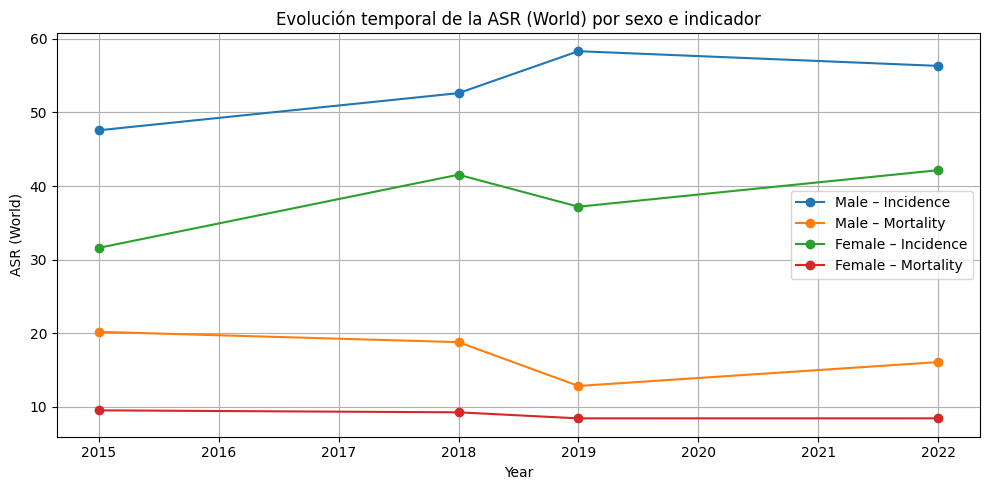

In [46]:
df_trend = (
    df_merged
    .dropna(subset=["Year", "ASR (World)", "Sex", "Type"])
    .groupby(["Year", "Sex", "Type"], as_index=False)
    .agg({"ASR (World)": "mean"})
    .sort_values("Year")
)

%matplotlib inline

plt.figure(figsize=(10,5))

for sex in ["Male", "Female"]:
    for t in ["Incidence", "Mortality"]:
        sub = df_trend[(df_trend["Sex"] == sex) & (df_trend["Type"] == t)]
        plt.plot(
            sub["Year"],
            sub["ASR (World)"],
            marker="o",
            label=f"{sex} – {t}"
        )

plt.xlabel("Year")
plt.ylabel("ASR (World)")
plt.title("Evolución temporal de la ASR (World) por sexo e indicador")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{fig_dir}/fig01_figure_ASR_anno.jpg", dpi=300, bbox_inches="tight")
plt.show()


#Se grafica entonces la evolución temporal de la ASR, estratificado por sexo

Se han organizado los datos que mas interesan

En la serie temporal se observa un incremento aparente de las tasas a partir de 2017, que no debe interpretarse como un aumento abrupto de la incidencia real del cáncer. Este comportamiento coincide con actualizaciones metodológicas introducidas por GLOBOCAN, así como con mejoras en los sistemas de diagnóstico y registro en numerosos países, lo que puede generar discontinuidades en las series temporales.


Por otro lado, El análisis principal durante esta primera exploración se centró en la incidencia del cáncer, utilizando tasas estandarizadas por edad (ASR World), y se realizó de forma separada por sexo con el fin de preservar las diferencias epidemiológicas observadas entre hombres y mujeres.

A partir del análisis exploratorio visual, se podría seleccionar el  año 2022 como periodo de referencia, al tratarse del año más reciente y menos afectado por las distorsiones observadas durante la pandemia de COVID-19. Sin embargo, primeramente se debe ver si merece la pena usar ese año o usar otro.





In [47]:
idx = (
    df_merged
    .groupby(["Country_harmonized", "Sex", "Type"])["Year"]
    .idxmax()
)

df_latest = df_merged.loc[idx].reset_index(drop=True)


<Figure size 1000x500 with 0 Axes>

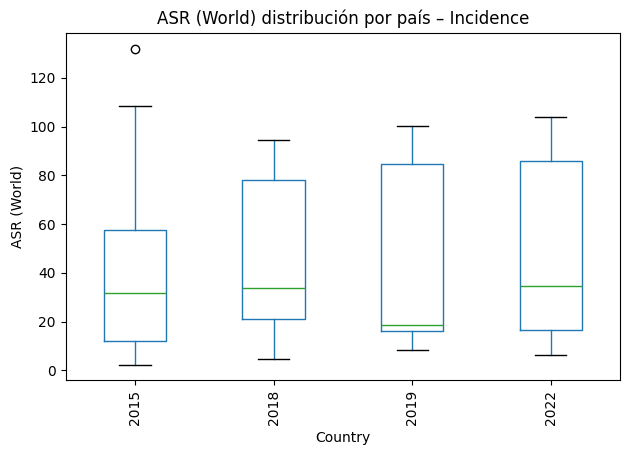

<Figure size 1000x500 with 0 Axes>

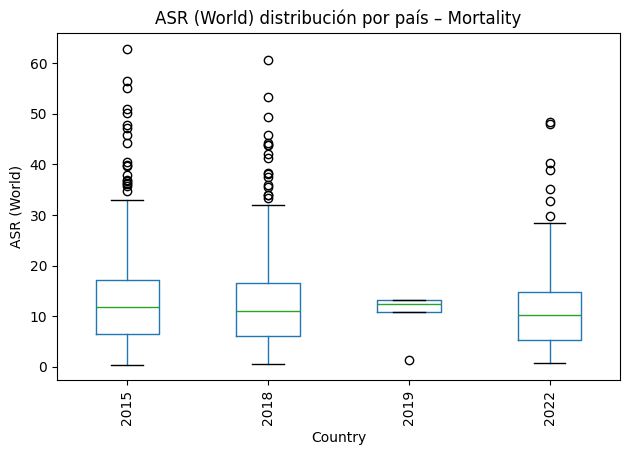

                count       mean        std       min        25%        50%  \
Type      Year                                                                
Incidence 2015  215.0  37.990913  29.337718  2.279390  11.803965  31.741894   
          2018   20.0  45.966859  32.841461  4.611827  21.016206  33.647772   
          2019    5.0  45.637514  43.287401  8.411226  16.197648  18.634292   
          2022   20.0  47.815407  35.812019  6.242416  16.589290  34.563362   
Mortality 2015  305.0  13.791938  10.723940  0.388140   6.427067  11.856669   
          2018  285.0  13.072164  10.119124  0.541023   6.054780  11.040429   
          2019    5.0  10.199604   5.044226  1.352979  10.780446  12.438318   
          2022  175.0  11.497300   8.685824  0.668701   5.292785  10.249669   

                      75%         max  
Type      Year                         
Incidence 2015  57.439240  132.046692  
          2018  77.994580   94.690075  
          2019  84.517821  100.426580  
         

In [48]:
df_plot = df_merged.copy()


for t in df_plot["Type"].unique():
    plt.figure(figsize=(10,5))

    df_plot[df_plot["Type"] == t].boxplot(
        column="ASR (World)",
        by="Year",
        grid=False,
        rot=90
    )

    plt.title(f"ASR (World) distribución por país – {t}")
    plt.suptitle("")
    plt.xlabel("Country")
    plt.ylabel("ASR (World)")
    plt.tight_layout()
    plt.savefig(f"{fig_dir}/fig02_boxplot_ASR_{t}.jpg", dpi=300, bbox_inches="tight")
    plt.show()

stats_simple = (
    df_plot
    .groupby(["Type", "Year"])["ASR (World)"]
    .describe()
)

print(stats_simple)



Estas figuras muestran la distribución de las tasas de incidencia y mortalidad estandarizadas por edad (ASR World) para el periodo 2007–2023 mediante diagramas de caja y bigotes. En ambos casos se observa una elevada heterogeneidad entre países, reflejada en amplios rangos intercuartílicos y la presencia sistemática de valores atípicos. La incidencia presenta una mayor dispersión que la mortalidad, lo que pone de manifiesto su mayor sensibilidad a factores como el diagnóstico precoz y la calidad de los registros. Por el contrario, la mortalidad muestra una distribución más estable y concentrada, lo que sugiere una mayor dependencia de la capacidad terapéutica de los sistemas sanitarios. Estas observaciones refuerzan la utilización de la mortalidad como variable principal, complementada por la incidencia.

Para continuar con el análisis estadístico y valorar que año y paises utilizar en nuestro trabajo, se busca entonces valorar que paises tienen los datos de incidencia y/o mortalidad.



In [49]:
df_merged = df_merged[df_merged["Year"] != 2019].copy()


In [50]:
#cuantos paises hay con año, tipo de cancer y tipo

counts = (
    df_merged
    .groupby(
        ["Country_harmonized", "Year", "Cancer label", "Type"]
    )
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

 # cuantos países tienen los datos completos (both) o incompletos?

counts["both"] = (
    (counts.get("Incidence", 0) > 0) &
    (counts.get("Mortality", 0) > 0)
)

counts["only_incidence"] = (
    (counts.get("Incidence", 0) > 0) &
    (counts.get("Mortality", 0) == 0)
)

counts["only_mortality"] = (
    (counts.get("Incidence", 0) == 0) &
    (counts.get("Mortality", 0) > 0)
)

summary = {
    "Total combinaciones país–año–cáncer": len(counts),
    "Con incidencia y mortalidad": counts["both"].sum(),
    "Solo incidencia": counts["only_incidence"].sum(),
    "Solo mortalidad": counts["only_mortality"].sum(),
}
print(
    f"Total combinaciones país–año–cáncer: {summary['Total combinaciones país–año–cáncer']}\n"
    f"Con incidencia y mortalidad: {summary['Con incidencia y mortalidad']}\n"
    f"Solo incidencia: {summary['Solo incidencia']}\n"
    f"Solo mortalidad: {summary['Solo mortalidad']}"
)


#Un resumen por año

by_year = (
    counts
    .groupby("Year")[["both", "only_incidence", "only_mortality"]]
    .sum()
)

print(by_year)

#resumen por pais

by_country = (
    counts
    .groupby("Country_harmonized")[["both", "only_incidence", "only_mortality"]]
    .sum()
    .sort_values("both")
)





Total combinaciones país–año–cáncer: 660
Con incidencia y mortalidad: 156
Solo incidencia: 48
Solo mortalidad: 456
Type  both  only_incidence  only_mortality
Year                                      
2015   140              32             104
2018     8               8             220
2022     8               8             132


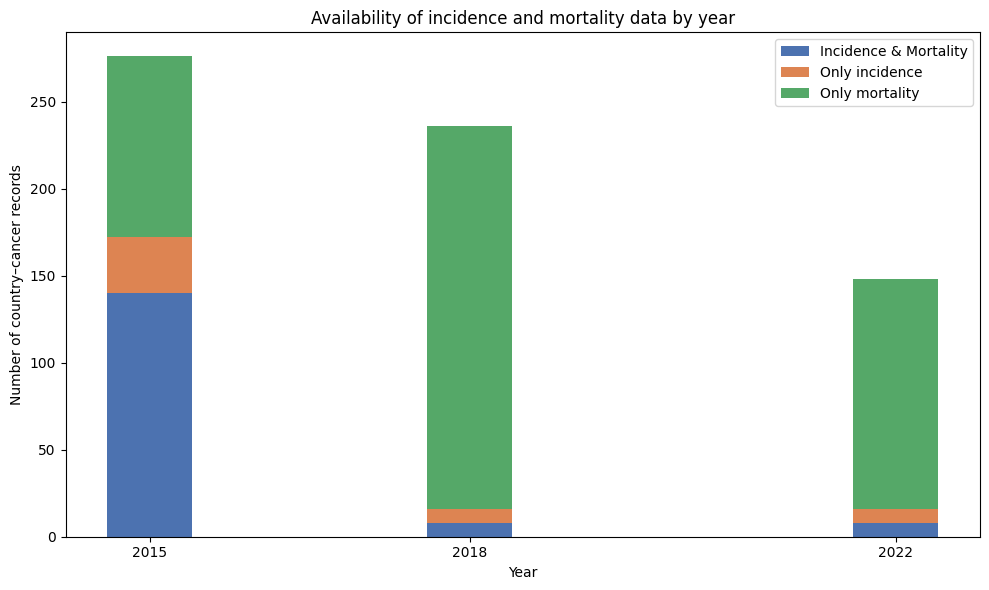

In [51]:
plt.figure(figsize=(10, 6))

plt.bar(
    by_year.index,
    by_year["both"],
    label="Incidence & Mortality",
    color="#4C72B0"
)

plt.bar(
    by_year.index,
    by_year["only_incidence"],
    bottom=by_year["both"],
    label="Only incidence",
    color="#DD8452"
)

plt.bar(
    by_year.index,
    by_year["only_mortality"],
    bottom=by_year["both"] + by_year["only_incidence"],
    label="Only mortality",
    color="#55A868"
)

plt.xlabel("Year")
plt.ylabel("Number of country–cancer records")
plt.title("Availability of incidence and mortality data by year")
plt.legend()
plt.tight_layout()
plt.xticks(by_year.index.astype(int))


plt.show()


Se observó una reducción generalizada en el número de países con datos disponibles a partir de 2018 para todos los tipos de cáncer analizados. Este cambio de cobertura limita la comparabilidad temporal de las medias anuales posteriores a dicho año, por lo que los análisis longitudinales se interpretan con cautela y se prioriza el uso de años con alta cobertura, concretamente 2018 y 2022.

Antes de integrar los datos de infraestructura sanitaria, se realizó un análisis exploratorio de la disponibilidad de los registros de incidencia y mortalidad por cáncer por país, año y tipo de cáncer, con el objetivo de evaluar la consistencia temporal y la comparabilidad de ambos indicadores. Este análisis permitió identificar limitaciones en la cobertura conjunta de incidencia y mortalidad a lo largo del tiempo.

A partir de 2017, los datos de incidencia muestran una cobertura insuficiente y heterogénea entre países y tipos de cáncer, lo que limita su uso en análisis comparativos globales. En contraste, la mortalidad mantiene una cobertura amplia y estable, por lo que se adopta como variable principal del estudio.

En consecuencia, el análisis se centra fundamentalmente en la mortalidad por cáncer. La incidencia se utiliza de forma exploratoria en los periodos en los que la disponibilidad de ambos indicadores lo permite, prestando especial atención a los años 2018 y 2022, que se evaluarán como posibles puntos de referencia para análisis comparativos transversales.

El análisis exploratorio de la cobertura geográfica por año mostró una estabilidad de datos incidencia y mortalidad elevada hasta 2016, seguida de una reducción progresiva en los años más recientes. Por este motivo, se busca además la cantidad de datos que se tienen por mortalidad compartiendo o no incidencia al mismo tiempo.
Esta estrategia permite evaluar la robustez de los resultados y analizar posibles cambios temporales sin comprometer la representatividad.


La mortalidad media se calculó de forma independiente para cada año y sexo, evitando mezclar periodos temporales con distinta cobertura y garantizando la comparabilidad entre 2016 y 2022, y 2018-22.

Las líneas discontinuas representan la mortalidad media (ASR World) de los  países registrado para los años 2016 y 2022, y 2018-22 respectivamente.
 Se observa que la mortalidad media masculina es sistemáticamente superior a la femenina, tanto en magnitud como en dispersión, lo que refuerza la necesidad de realizar análisis estratificados por sexo.

Para saber hasta donde llegan nuestro alcance con los datos si se consideran tanto incidencia como mortalidad, graficamos el número de países registrados por año

/tmp/ipython-input-3777147155.py:56: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Cancer type", bbox_to_anchor=(1.02, 1), loc="upper left")


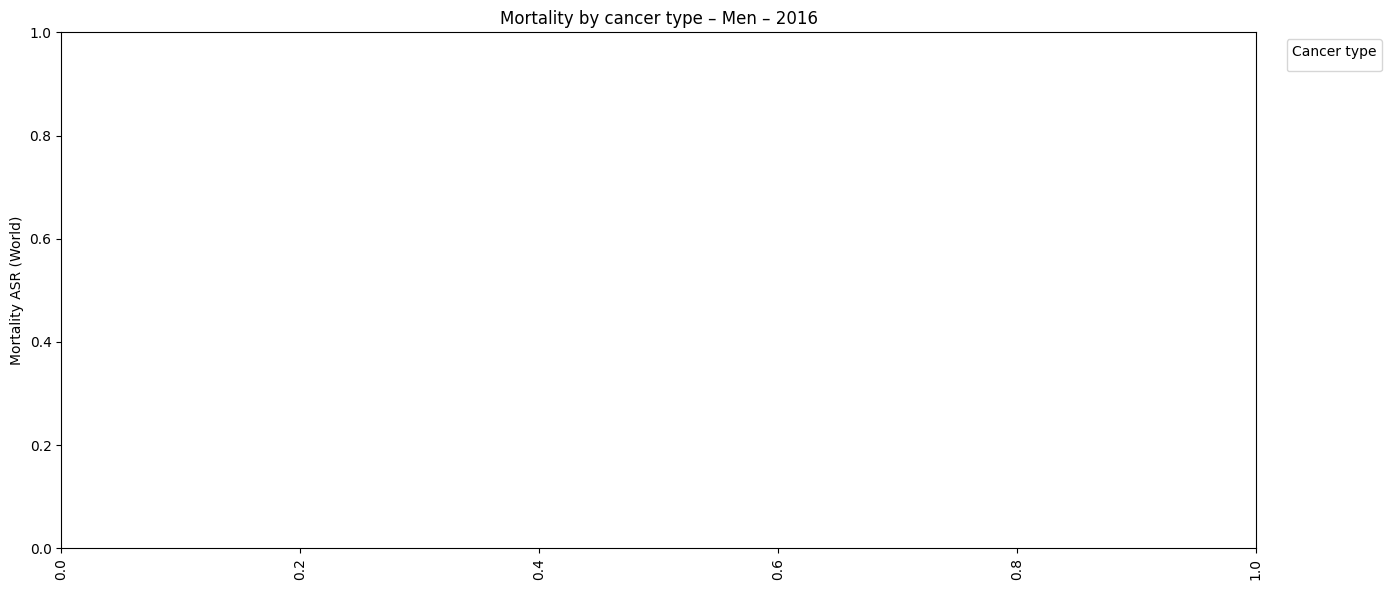

/tmp/ipython-input-3777147155.py:56: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Cancer type", bbox_to_anchor=(1.02, 1), loc="upper left")


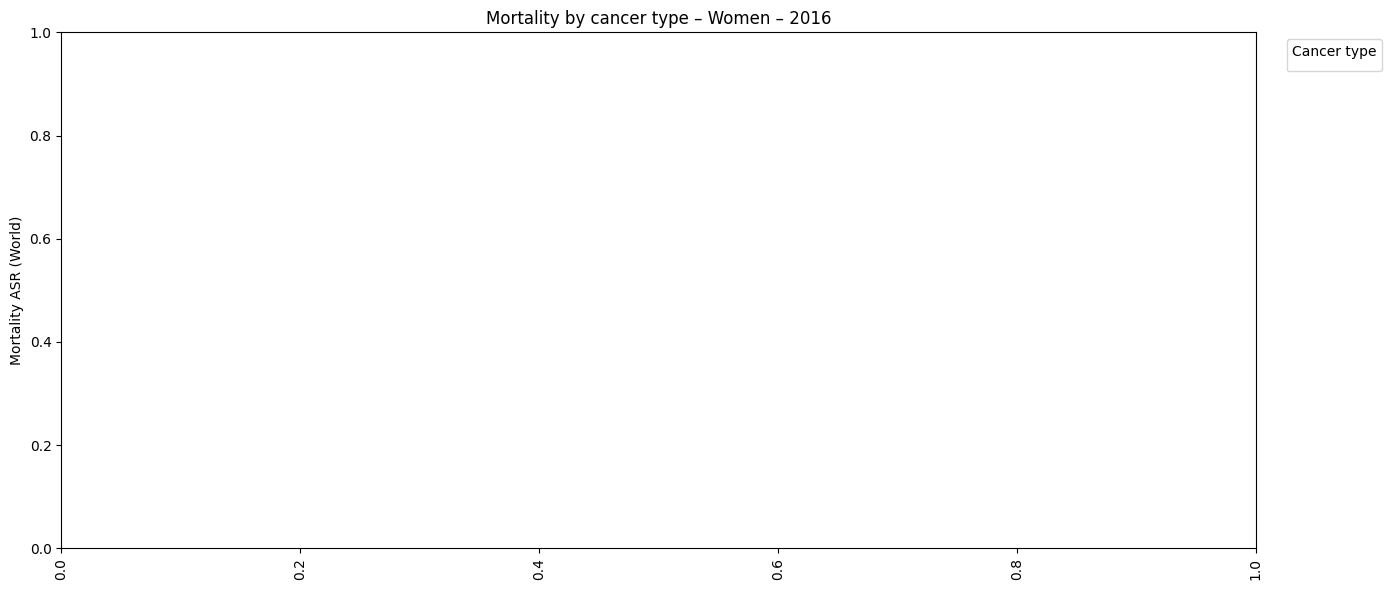

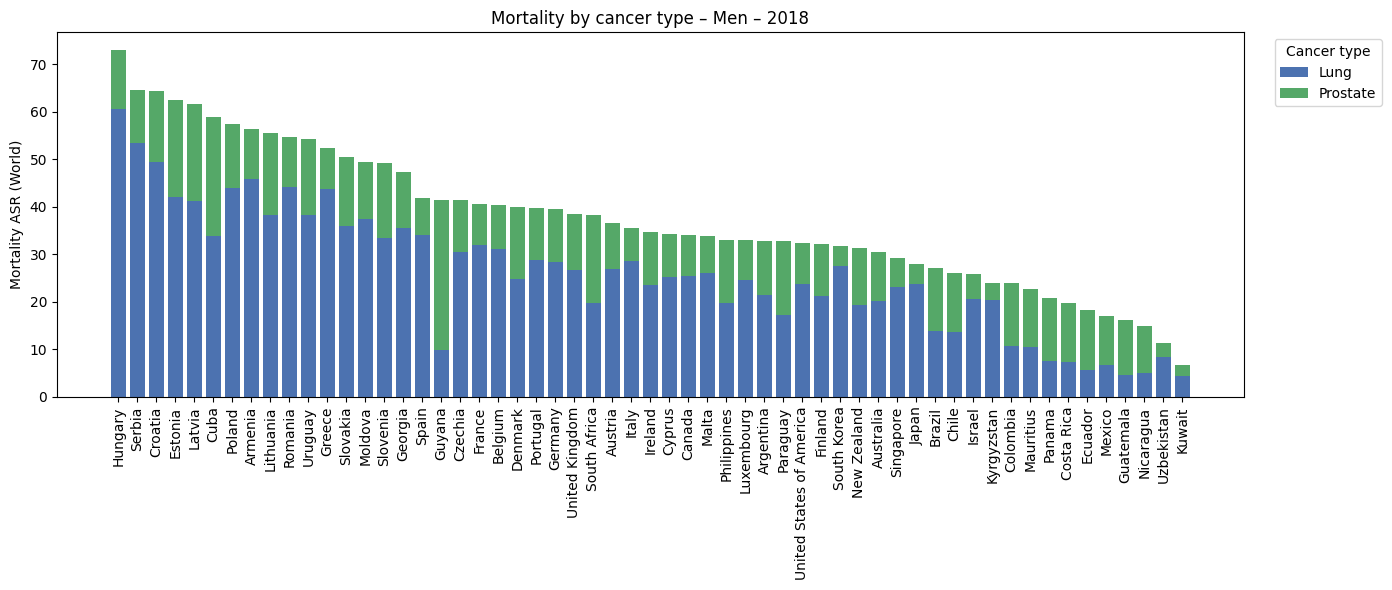

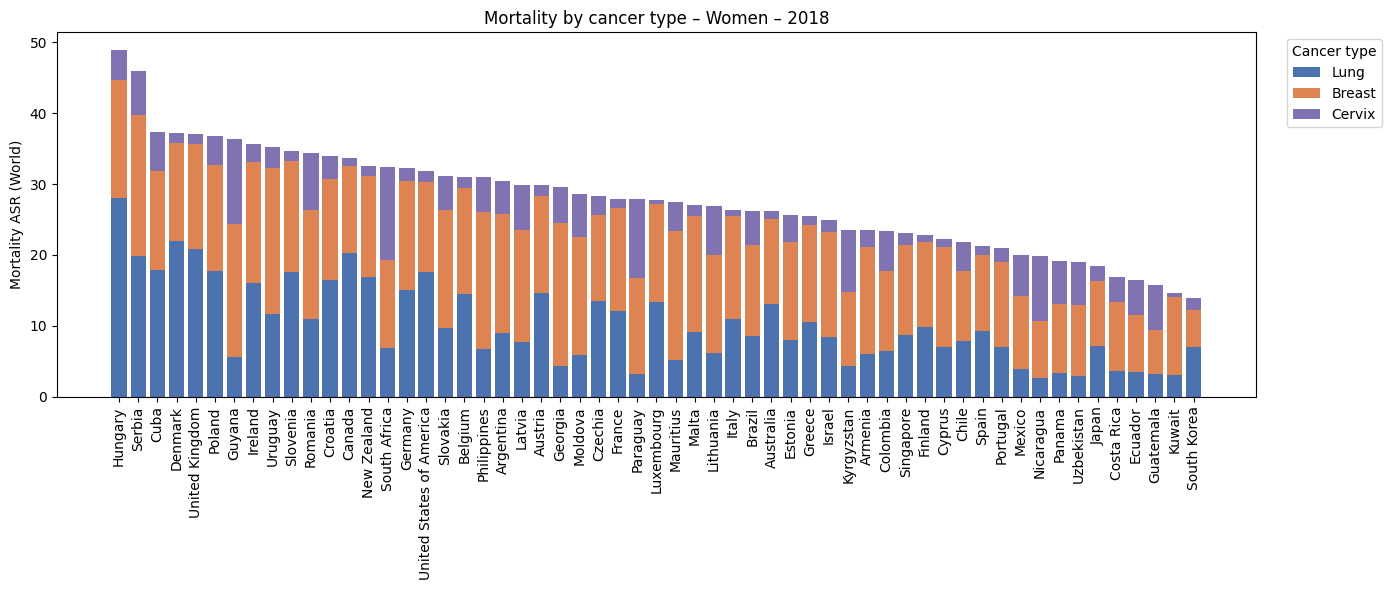

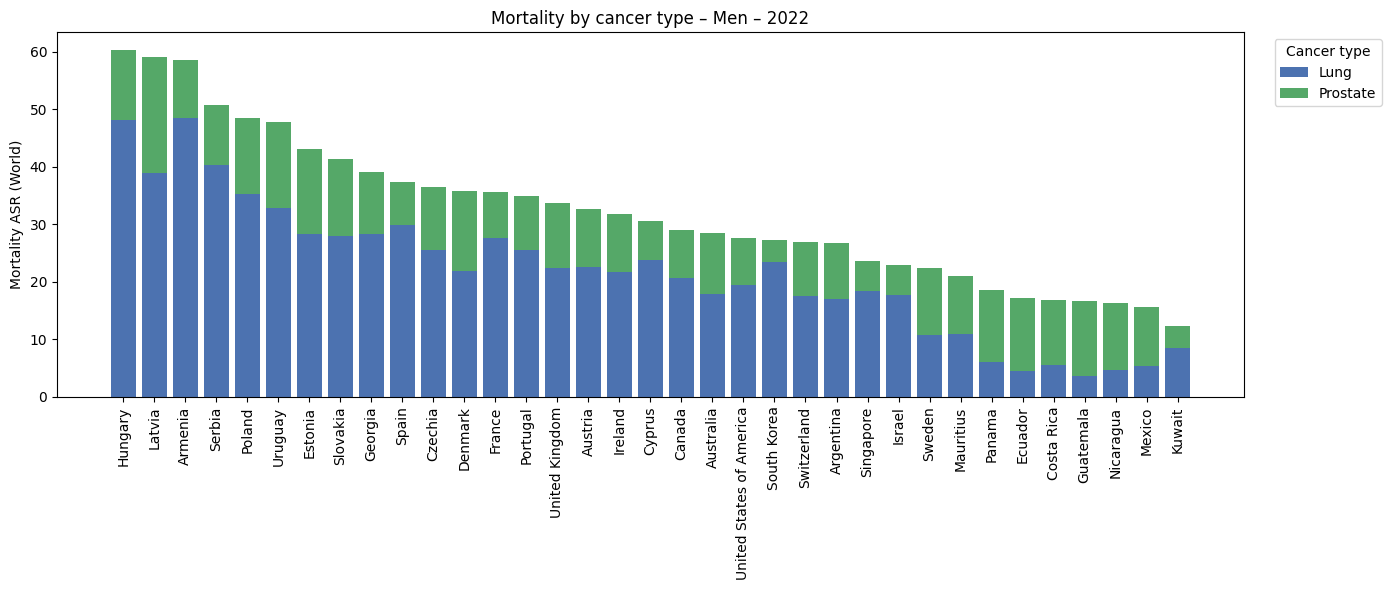

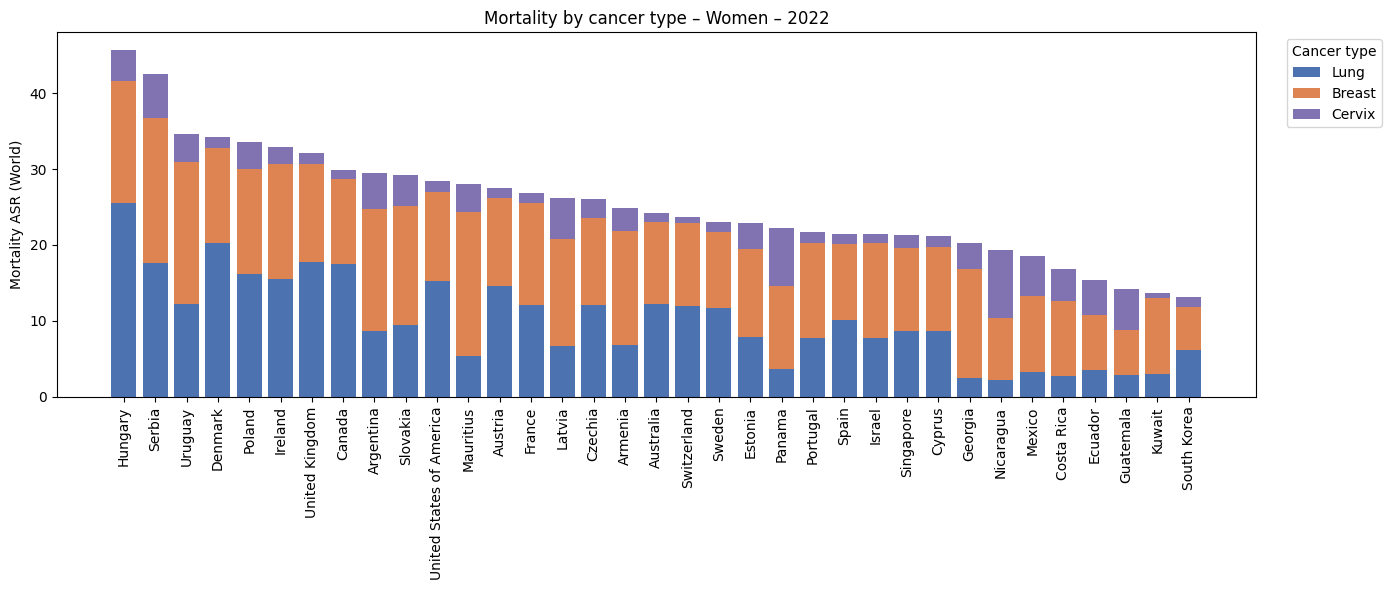

In [52]:
#cada tipo de cancer, un color distinto

cancer_colors = {
    "Lung": "#4C72B0",        # azul
    "Breast": "#DD8452",      # naranja
    "Prostate": "#55A868",    # verde
    "Colon": "#C44E52",       # rojo
    "Cervix": "#8172B2",# morado
}

#Preparar por año y sexo la mortalidad para agrupar por pais y tipo de cancer
def prepare_stacked_mortality_by_sex(df, year, sex):
    df_y = df[
        (df["Year"] == year) &
        (df["Type"] == "Mortality") &
        (df["Sex"] == sex)
    ].copy()

    agg = (
        df_y
        .groupby(["Country_harmonized", "Cancer label"], as_index=False)
        .agg({"ASR (World)": "mean"})
    )

    return agg


def pivot_stacked(df_agg):
    pivot = df_agg.pivot(
        index="Country_harmonized",
        columns="Cancer label",
        values="ASR (World)"
    ).fillna(0)

    return pivot

#función para graficar las barras por país la mortalidad
def plot_stacked_mortality_by_sex(pivot, year, sex_label, fig_dir=None):
    plt.figure(figsize=(14, 6))

    bottom = np.zeros(len(pivot))

    for cancer in pivot.columns:
        plt.bar(
            pivot.index,
            pivot[cancer],
            bottom=bottom,
            label=cancer,
            color=cancer_colors[cancer] # Use cancer to get color dynamically
        )
        bottom += pivot[cancer].values

    plt.xticks(rotation=90)
    plt.ylabel("Mortality ASR (World)")
    plt.title(f"Mortality by cancer type – {sex_label} – {year}")
    plt.legend(title="Cancer type", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()

    if fig_dir:
        plt.savefig(
            f"{fig_dir}/stacked_mortality_{sex_label}_{year}.jpg",
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()



# 2016

#Para hombres
mort_2016_m = prepare_stacked_mortality_by_sex(df_merged, 2016, "Male")



pivot_2016_m_full = pivot_stacked(mort_2016_m)
existing_cancer_keys_m = [key for key in cancer_colors.keys() if key in pivot_2016_m_full.columns]
pivot_2016_m = pivot_2016_m_full[existing_cancer_keys_m]

pivot_2016_m = pivot_2016_m.loc[
    pivot_2016_m.sum(axis=1).sort_values(ascending=False).index
]

#para mujeres
mort_2016_f = prepare_stacked_mortality_by_sex(df_merged, 2016, "Female")
pivot_2016_f_full = pivot_stacked(mort_2016_f)
existing_cancer_keys_f = [key for key in cancer_colors.keys() if key in pivot_2016_f_full.columns]
pivot_2016_f = pivot_2016_f_full[existing_cancer_keys_f]

pivot_2016_f = pivot_2016_f.loc[
    pivot_2016_f.sum(axis=1).sort_values(ascending=False).index
]


plot_stacked_mortality_by_sex(
    pivot_2016_m,
    2016,
    "Men",
    fig_dir
)

plot_stacked_mortality_by_sex(
    pivot_2016_f,
    2016,
    "Women",
    fig_dir
)


#2018

#Para hombres
mort_2018_m = prepare_stacked_mortality_by_sex(df_merged, 2018, "Male")



pivot_2018_m_full = pivot_stacked(mort_2018_m)
existing_cancer_keys_m = [key for key in cancer_colors.keys() if key in pivot_2018_m_full.columns]
pivot_2018_m = pivot_2018_m_full[existing_cancer_keys_m]

pivot_2018_m = pivot_2018_m.loc[
    pivot_2018_m.sum(axis=1).sort_values(ascending=False).index
]

#para mujeres
mort_2018_f = prepare_stacked_mortality_by_sex(df_merged, 2018, "Female")
pivot_2018_f_full = pivot_stacked(mort_2018_f)
existing_cancer_keys_f = [key for key in cancer_colors.keys() if key in pivot_2018_f_full.columns]
pivot_2018_f = pivot_2018_f_full[existing_cancer_keys_f]

pivot_2018_f = pivot_2018_f.loc[
    pivot_2018_f.sum(axis=1).sort_values(ascending=False).index
]


plot_stacked_mortality_by_sex(
    pivot_2018_m,
    2018,
    "Men",
    fig_dir
)

plot_stacked_mortality_by_sex(
    pivot_2018_f,
    2018,
    "Women",
    fig_dir
)


# 2022
#graficar para hombres
mort_2022_m = prepare_stacked_mortality_by_sex(df_merged, 2022, "Male")

pivot_2022_m_full = pivot_stacked(mort_2022_m)
existing_cancer_keys_m_2022 = [key for key in cancer_colors.keys() if key in pivot_2022_m_full.columns]
pivot_2022_m = pivot_2022_m_full[existing_cancer_keys_m_2022]

pivot_2022_m = pivot_2022_m.loc[
    pivot_2022_m.sum(axis=1).sort_values(ascending=False).index
]

#graficar Para mujeres
mort_2022_f = prepare_stacked_mortality_by_sex(df_merged, 2022, "Female")
pivot_2022_f_full = pivot_stacked(mort_2022_f)
existing_cancer_keys_f_2022 = [key for key in cancer_colors.keys() if key in pivot_2022_f_full.columns]
pivot_2022_f = pivot_2022_f_full[existing_cancer_keys_f_2022]

pivot_2022_f = pivot_2022_f.loc[
    pivot_2022_f.sum(axis=1).sort_values(ascending=False).index
]


plot_stacked_mortality_by_sex(
    pivot_2022_m,
    2022,
    "Men",
    fig_dir
)

plot_stacked_mortality_by_sex(
    pivot_2022_f,
    2022,
    "Women",
    fig_dir
)

In [53]:
df_merged.head()

,Cancer label,Sex,Type,Year,ASR (World),Crude rate,Cumulative risk,Total,Country_harmonized,Indicator,Region Name,Year_Units,RT_m,Population,Population_male,Population_female,GDP_per_capita
0,Lung,Male,Incidence,2015,58.426413,85.680378,7.429043,3747,Belarus,Total density per million population: Radiothe...,Europe,2010,3.02,9487293.0,4414172.0,5073122.0,5967.055951
1,Lung,Female,Incidence,2015,6.135969,12.461069,0.772077,634,Belarus,Total density per million population: Radiothe...,Europe,2010,3.02,9487293.0,4414172.0,5073122.0,5967.055951
2,Lung,Male,Incidence,2015,35.368583,70.075779,4.220175,9215,Canada,Total density per million population: Radiothe...,Americas,2010,8.73,35962234.0,17837661.0,18124573.0,43594.194105
3,Lung,Male,Mortality,2015,28.561064,59.755594,3.281947,10659,Canada,Total density per million population: Radiothe...,Americas,2010,8.73,35962234.0,17837661.0,18124573.0,43594.194105
4,Lung,Male,Mortality,2018,25.348546,56.824415,2.843197,10521,Canada,Total density per million population: Radiothe...,Americas,2013,8.07,37295005.0,18514929.0,18780076.0,46539.176157


A continuación se hará un primer análisis sobre incidencia y mortalidad.


In [54]:
# Reconstruct necessary variables for plotting, based on previously deleted cells.
# This block re-introduces the logic from cells like OiBBxBrLS3xz and 0PlXrLQiroWw.

# Filter df_merged to create df_male, df_female, df_complete needed for pivot
# Note: df_merged was already filtered for 'Year' != 2019 in cell 1lmioakCyOPm.

df_male = df_merged[df_merged["Sex"] == "Male"].copy()
df_female = df_merged[df_merged["Sex"] == "Female"].copy()

# Identify combinations of Country_harmonized, Year, Sex that have both Incidence and Mortality
complete_keys = (
    df_merged
    .groupby(["Country_harmonized", "Year", "Sex"])["Type"]
    .nunique()
    .reset_index()
    .query("Type == 2") # '2' means both 'Incidence' and 'Mortality' are present
)

# Filter df_merged to only include complete records (both incidence and mortality)
df_complete = df_merged.merge(
    complete_keys[["Country_harmonized", "Year", "Sex"]],
    on=["Country_harmonized", "Year", "Sex"],
    how="inner"
)

def build_pivot(df):
    df_scatter = (
        df
        .groupby(
            ["Country_harmonized", "Year", "Type"],
            as_index=False
        )
        .agg({"ASR (World)": "mean"})
    )

    pivot = (
        df_scatter
        .pivot_table(
            index=["Country_harmonized", "Year"],
            columns="Type",
            values="ASR (World)"
        )
        .reset_index()
    )

    return pivot

pivot_male = build_pivot(df_male)
pivot_female = build_pivot(df_female)
pivot_all = build_pivot(df_complete)

# Clean pivots by dropping rows where either Incidence or Mortality is NaN
pivot_male_clean = pivot_male.dropna(subset=["Incidence", "Mortality"])
pivot_female_clean = pivot_female.dropna(subset=["Incidence", "Mortality"])

# Extract x and y values for plotting
x_f = pivot_female_clean["Incidence"].values
y_f = pivot_female_clean["Mortality"].values
x_m = pivot_male_clean["Incidence"].values
y_m = pivot_male_clean["Mortality"].values

# Define the function to compute beta, alpha, and R
def compute_beta_R(df):
    x = df["Incidence"].values
    y = df["Mortality"].values

    # Check for sufficient data points
    if len(x) < 2 or len(y) < 2: # np.polyfit requires at least 2 points
        return np.nan, np.nan, np.nan

    beta, alpha = np.polyfit(x, y, 1)
    R = np.corrcoef(x, y)[0, 1]

    return beta, alpha, R

# Compute beta, alpha, and R for female and male data
beta_f, alpha_f, R_f = compute_beta_R(pivot_female_clean)
beta_m, alpha_m, R_m = compute_beta_R(pivot_male_clean)
beta_all, alpha_all, R_all = compute_beta_R(pivot_all) # Also compute for all data if needed later

print(f"Female  -> beta={beta_f:.3f}, alpha={alpha_f:.3f}, R={R_f:.3f}, N={len(pivot_female_clean)}")
print(pivot_female_clean.head())

print(f"Male    -> beta={beta_m:.3f},  alpha={alpha_m:.3f},  R={R_m:.3f},  N={len(pivot_male_clean)}")
print(pivot_male_clean.head())

print(f"All    -> beta={beta_all:.3f},  alpha={alpha_all:.3f},  R={R_all:.3f},  N={len(pivot_all)}")
print(pivot_all.head())


Female  -> beta=0.174, alpha=3.460, R=0.591, N=39
Type Country_harmonized  Year  Incidence  Mortality
0             Argentina  2015  30.844289  10.527891
6             Australia  2015  39.926102   9.302131
9               Austria  2015  31.763929  10.131833
18               Canada  2015  40.095023  12.310902
21                Chile  2015  16.301623   7.749648
Male    -> beta=0.280,  alpha=5.164,  R=0.661,  N=39
Type Country_harmonized  Year  Incidence  Mortality
0             Argentina  2015  30.044158  18.513924
6             Australia  2015  62.976221  16.486398
9               Austria  2015  48.863711  18.669471
18               Canada  2015  48.998152  18.790837
21                Chile  2015  31.791339  14.028698
All    -> beta=0.219,  alpha=4.496,  R=0.575,  N=39
Type Country_harmonized  Year  Incidence  Mortality
0             Argentina  2015  30.524237  13.722304
1             Australia  2015  49.146150  12.175838
2               Austria  2015  38.603842  13.546888
3            

Al estratificar el análisis por sexo, se observan diferencias claras en la relación entre incidencia y mortalidad. En hombres, la pendiente del modelo es mayor, lo que indica un incremento más acusado de la mortalidad a medida que aumenta la incidencia. En mujeres, la relación es menos pronunciada pero más consistente, reflejada en un coeficiente de correlación superior. Por el contrario, el análisis agregado por sexo presenta una menor capacidad explicativa, lo que evidencia que la agregación de ambos sexos introduce heterogeneidad y enmascara patrones relevantes





Esta gráfica nos indica que a medida que se incrementa la incidencia, la mortalidad también incremente, sin embargo, al ver tanta dispersión vertical, lo que puede sugerir es que el riesgo de morir no solamente depende de cuantos casos hay, sino de factores como acceso al tratamientos, detección precoz, infraestructura (radioterapia), pib per cápita, etc. Al ver el comportamiento a lo largo del tiempo, se muestra que la relación incidencia-mortalidad es estructural.

En este gráfico se puede ver cuan diferente es si se grafica lo mismo incidencia-mortalidad pero en hombres, donde la pendiente es más pronunciada y presenta mayor dispersión vertical. Dando lugar a preguntas como, ¿que ocurre con el acceso a los tratamientos? y en nuestro caso, a las instalaciones de radioterapia.

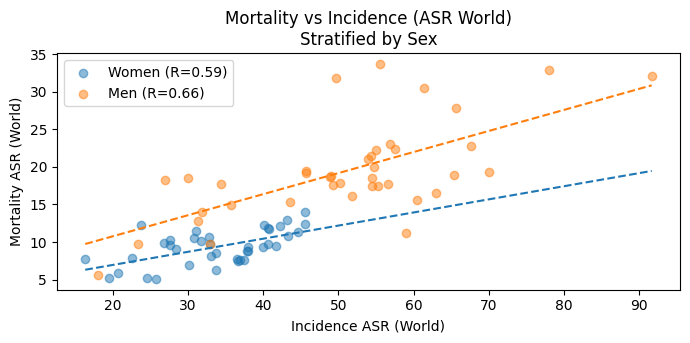

In [55]:
plt.figure(figsize=(7, 7))

plt.scatter(
    x_f, y_f,
    alpha=0.5,
    label=f"Women (R={R_f:.2f})"
)

plt.scatter(
    x_m, y_m,
    alpha=0.5,
    label=f"Men (R={R_m:.2f})"
)

# rectas
x_min = min(x_f.min(), x_m.min())
x_max = max(x_f.max(), x_m.max())
x_line = np.linspace(x_min, x_max, 200)

plt.plot(x_line, beta_f * x_line + alpha_f, linestyle="--")
plt.plot(x_line, beta_m * x_line + alpha_m, linestyle="--")

plt.xlabel("Incidence ASR (World)")
plt.ylabel("Mortality ASR (World)")
plt.title("Mortality vs Incidence (ASR World)\nStratified by Sex")

plt.legend()
plt.gca().set_aspect("equal", adjustable="box")
plt.grid(False)
plt.tight_layout()
plt.show()


Las representaciones gráficas de la relación entre incidencia y mortalidad estandarizadas por edad revelan patrones claramente diferenciados por sexo. En el caso de los hombres, se observa una pendiente más pronunciada y una mayor dispersión de los datos, lo que indica que incrementos en la incidencia se asocian con aumentos más acusados de la mortalidad. En las mujeres, la relación es más moderada y presenta una mayor consistencia, de modo que la mortalidad aumenta de forma más gradual con la incidencia.

Los coeficientes de correlación observados (R ≈ 0.60 en hombres y R ≈ 0.63 en mujeres) indican una asociación positiva de magnitud moderada en ambos sexos, lo que sugiere que la incidencia explica solo parcialmente la variabilidad en la mortalidad. La superposición de ambos grupos en un análisis agregado oculta estas diferencias estructurales, lo que justifica la estratificación por sexo adoptada en este estudio.

Asimismo, la mayor pendiente y dispersión observadas en los hombres apuntan a una relación más intensa entre incidencia y mortalidad, potencialmente relacionada con diferencias en los tipos de cáncer predominantes, los perfiles de riesgo y el acceso al diagnóstico precoz y al tratamiento. Estos resultados refuerzan la necesidad de ampliar el análisis incorporando variables adicionales, como el PIB per cápita y la disponibilidad de equipos de radioterapia, con el fin de explorar factores explicativos de las diferencias observadas en la mortalidad.



Justificación del uso de la mortalidad como variable de resultado (2016–2022)

Con el objetivo de garantizar la comparabilidad temporal y maximizar la cobertura geográfica del análisis, se evaluó la disponibilidad de datos de incidencia y mortalidad para los años 2016, 2018 y 2022, que constituyen los dos puntos temporales de referencia en este estudio.

El año 2016 representa el último periodo en el que una proporción sustancial de países dispone simultáneamente de datos de incidencia y mortalidad, permitiendo una caracterización relativamente completa de ambos indicadores. Sin embargo, en 2022 se observa un cambio estructural muy marcado en la disponibilidad de los datos: la mayoría de los registros país–cáncer corresponden exclusivamente a mortalidad, mientras que los datos de incidencia están disponibles únicamente para un número reducido de países.

Este contraste implica que el uso de la incidencia, o de modelos que requieran simultáneamente incidencia y mortalidad, conduciría en 2022 a una reducción drástica del tamaño muestral y a un sesgo hacia países con sistemas de registro oncológico más desarrollados. En cambio, la mortalidad mantiene una cobertura geográfica amplia y homogénea en ambos años, permitiendo una comparación consistente entre países y a lo largo del tiempo.

Dado que el objetivo del trabajo es analizar la relación entre los resultados en cáncer y la disponibilidad de infraestructuras de radioterapia, se selecciona la mortalidad como variable principal utilizando el año 2022. Esta elección permite maximizar el número de países incluidos, garantizar la coherencia temporal del análisis y centrarse en un desenlace clínico final estrechamente vinculado al acceso y la efectividad de los tratamientos oncológicos.

Se realizará lo mismo con el año 2018.



###DIRAC

A partir de esta evaluación, los análisis posteriores se centran exclusivamente en la mortalidad por cáncer, que se relaciona con la disponibilidad de infraestructura de radioterapia (DIRAC) y se ajusta por población.

Ahora, se construye el primer scatter con indice de mortalidad vs centros de radioterapia existentes. Para esto, es necesario normalizar la infraestructura por población, es decir, RT centers y equipos por millón de habitantes.

In [56]:
df_merged_all = df_merged.copy()

# Quedarse solo con mortalidad
df_merged_all = df_merged_all[df_merged_all["Type"] == "Mortality"].copy()

# Ver qué años hay y cuántas observaciones por año
df_merged_all["Year"].value_counts().sort_index()


,count
Year,
2015,305
2018,285
2022,175


In [57]:
df_merged_all["log_GDP_per_capita"] = np.log(df_merged_all["GDP_per_capita"] + 1)


# 3. Guardar dataset limpio
df_merged_all.to_csv("df_merged_clean.csv", index=False)

En la literatura técnica y en estudios revisados por pares, se utiliza comúnmente como referencia un benchmark de aproximadamente una máquina de radioterapia de megavoltaje por cada 250 000 habitantes, atribuido a las directrices de la IAEA para planificación de servicios de radioterapia.


In [58]:

df_merged_all.head()

,Cancer label,Sex,Type,Year,ASR (World),Crude rate,Cumulative risk,Total,Country_harmonized,Indicator,Region Name,Year_Units,RT_m,Population,Population_male,Population_female,GDP_per_capita,log_GDP_per_capita
3,Lung,Male,Mortality,2015,28.561064,59.755594,3.281947,10659,Canada,Total density per million population: Radiothe...,Americas,2010,8.73,35962234.0,17837661.0,18124573.0,43594.194105,10.682702
4,Lung,Male,Mortality,2018,25.348546,56.824415,2.843197,10521,Canada,Total density per million population: Radiothe...,Americas,2013,8.07,37295005.0,18514929.0,18780076.0,46539.176157,10.748071
5,Lung,Male,Mortality,2022,20.689747,50.979249,2.350679,9830,Canada,Total density per million population: Radiothe...,Americas,2017,9.30,38821259.0,19282356.0,19538904.0,56256.800726,10.937700
7,Lung,Female,Mortality,2015,22.576579,52.028810,2.762246,9430,Canada,Total density per million population: Radiothe...,Americas,2010,8.73,35962234.0,17837661.0,18124573.0,43594.194105,10.682702
8,Lung,Female,Mortality,2018,20.226551,50.489679,2.409769,9482,Canada,Total density per million population: Radiothe...,Americas,2013,8.07,37295005.0,18514929.0,18780076.0,46539.176157,10.748071


In [59]:
df_merged_all["Cancer label"].unique()

array(['Lung', 'Breast', 'Prostate', 'Cervix'], dtype=object)

Como se está bien investigado, el PIB per capita predomina en este tipo de analisis, así que se grafica

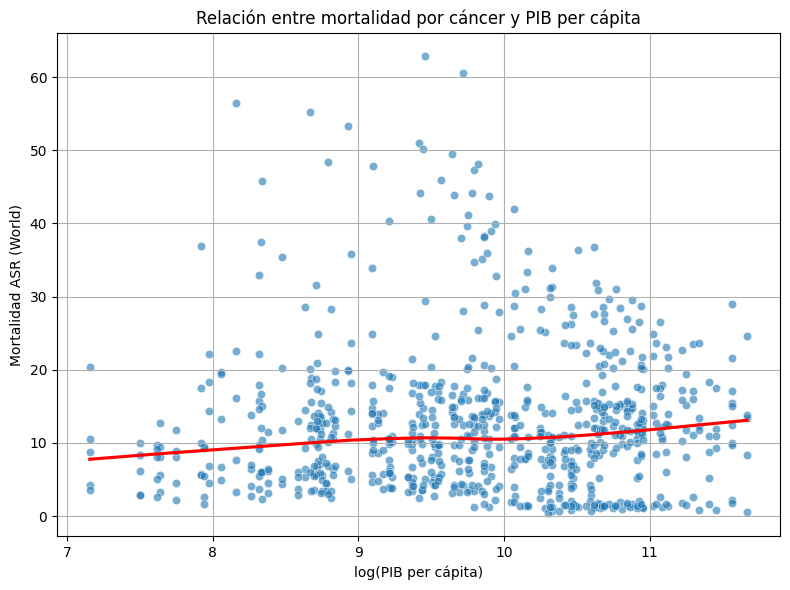

In [88]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Filtramos solo mortalidad (coherente con tu modelo final)
df_pib = df_merged[df_merged["Type"] == "Mortality"].copy()

# Transformación logarítmica del PIB

df_pib["log_GDP_pc"] = np.log(df_pib["GDP_per_capita"])

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df_pib,
    x="log_GDP_pc",
    y="ASR (World)",
    alpha=0.6
)

# Línea suave (LOWESS)
sns.regplot(
    data=df_pib,
    x="log_GDP_pc",
    y="ASR (World)",
    scatter=False,
    lowess=True,
    color="red"
)

plt.xlabel("log(PIB per cápita)")
plt.ylabel("Mortalidad ASR (World)")
plt.title("Relación entre mortalidad por cáncer y PIB per cápita")
plt.grid(True)
plt.tight_layout()
plt.show()


Se grafican los valores dispersos de mortalidad y equipos de radioterapias varios, empezando con búsquedas (sin mucha pretención) de comportamientos lineales.
Primer modelo lineal:

In [60]:
#definimos el primer modelo

df_model = df_merged_all[
    (df_merged_all["Type"] == "Mortality")
].copy()

# Rename 'Cancer label' to 'Cancer_label' to avoid issues with statsmodels formula parsing
df_model = df_model.rename(columns={"Cancer label": "Cancer_label"})


In [61]:
#dispersión por sexo y cancer
def scatter_by_sex_cancer_year(
    df, cancer, sex, rt_var_pm, years=[2015, 2018]
):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

    for ax, year in zip(axes, years):
        df_y = df[
            (df["Cancer_label"] == cancer) &
            (df["Sex"] == sex) &
            (df["Year"] == year)
        ]

        ax.scatter(
            df_y[rt_var_pm],
            df_y["ASR (World)"],

            alpha=0.7
        )

        ax.set_title(f"{year}")
        ax.set_xlabel(
            rt_var_pm.replace("_m", "")
            + "\n(per million inhabitants)"
        )

    axes[0].set_ylabel("Mortality ASR (World)")
    plt.suptitle(f"{cancer} – {sex}")
    plt.tight_layout()
    plt.show()

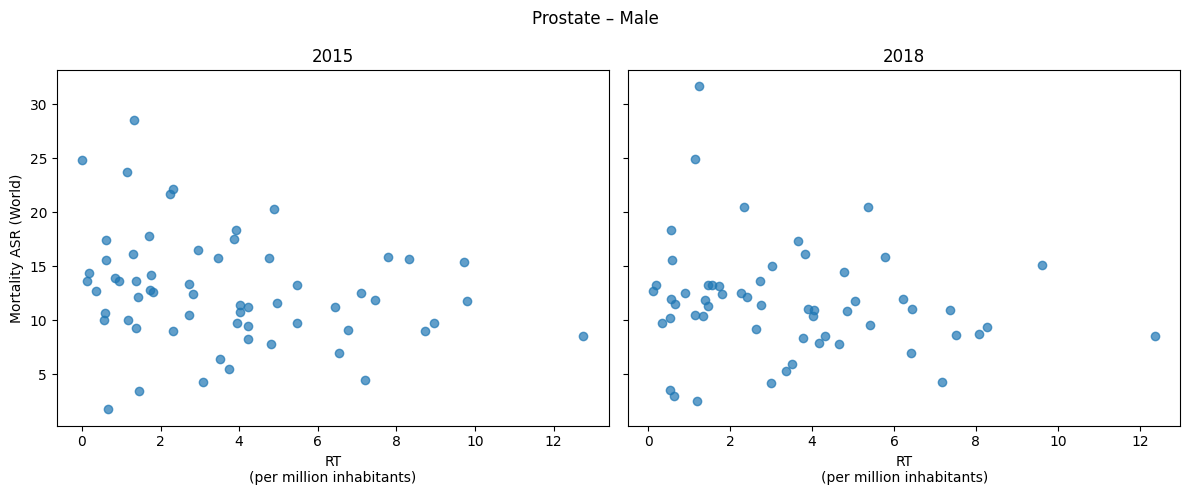

In [62]:
scatter_by_sex_cancer_year(
    df_model,
    cancer="Prostate",
    sex="Male",
    rt_var_pm="RT_m"
)

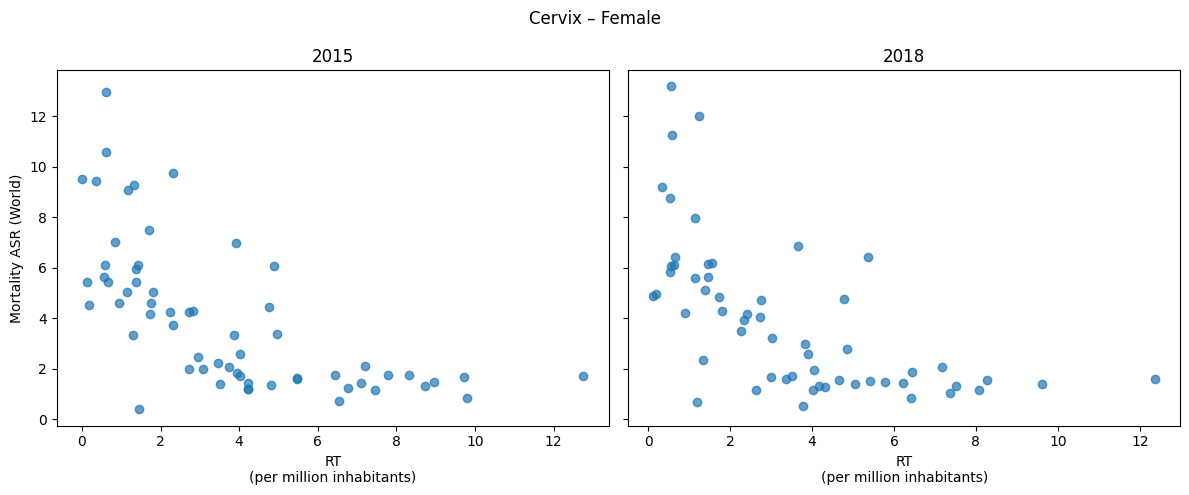

In [63]:
scatter_by_sex_cancer_year(
    df_model,
    cancer="Cervix",
    sex="Female",
    rt_var_pm="RT_m"
)


Esto demuestra el umbral de capacidad sanitaria sobretodo en cancer de cervix, mas adelante se verá lo que ocurre.

In [64]:
import numpy as np
from scipy import stats

def rt_m_mortality_analysis(df, year):
    df_y = df[
        (df["Year"] == year) &
        (df["RT_m"].notna()) &
        (df["ASR (World)"].notna())
    ]

    x = df_y["RT_m"].values
    y = df_y["ASR (World)"].values

    return x, y
# 2018
rt_2018, mort_2018 = rt_m_mortality_analysis(df_model, 2018)
r_2018, p_2018 = stats.pearsonr(rt_2018, mort_2018)

# 2022
rt_2015, mort_2015 = rt_m_mortality_analysis(df_model, 2015)
r_2015, p_2015 = stats.pearsonr(rt_2015, mort_2015)

print(f"Correlación 2018: r={r_2018:.3f}, p={p_2018:.3f}")
print(f"Correlación 2015: r={r_2015:.3f}, p={p_2015:.3f}")

slope_2018, intercept_2018, r_val_2018, p_val_2018, _ = \
    stats.linregress(rt_2018, mort_2018)

print("\nRegresión 2018:")
print(f"  Pendiente: {slope_2018:.3f} (Δ mortalidad por unidad RT_m)")
print(f"  R²: {r_val_2018**2:.3f}")
print(f"  p-value: {p_val_2018:.3f}")

threshold = 5  # RT por millón

low_rt = mort_2015[rt_2015 < threshold]
high_rt = mort_2015[rt_2015 >= threshold]

print("\n2015 - Mortalidad promedio:")
print(f"  RT_m < {threshold}: {np.mean(low_rt):.2f} ASR")
print(f"  RT_m ≥ {threshold}: {np.mean(high_rt):.2f} ASR")
print(f"  Diferencia: {np.mean(low_rt) - np.mean(high_rt):.2f} ASR")

t_stat, p_value = stats.ttest_ind(low_rt, high_rt, equal_var=False)
print(f"  t-test p-value: {p_value:.3f}")



Correlación 2018: r=0.067, p=0.258
Correlación 2015: r=0.054, p=0.348

Regresión 2018:
  Pendiente: 0.255 (Δ mortalidad por unidad RT_m)
  R²: 0.005
  p-value: 0.258

2015 - Mortalidad promedio:
  RT_m < 5: 13.76 ASR
  RT_m ≥ 5: 13.88 ASR
  Diferencia: -0.11 ASR
  t-test p-value: 0.929


No es útil un modelo lineal

In [65]:
df_model = df_model[df_model["Year"].isin([2015, 2018])].copy()

df_model["Period"] = df_model["Year"].map({
    2015: "2015",
    2018: "2018"
})


In [66]:
#Binarizar la mortalidad
threshold = df_model["ASR (World)"].median()

df_model["High_Mortality"] = (
    df_model["ASR (World)"] > threshold
).astype(int)


In [67]:
from optbinning import OptimalBinning

optb = OptimalBinning(
    name="RT_m",
    dtype="numerical",
    solver="cp"
)

optb.fit(
    df_model["RT_m"],
    df_model["High_Mortality"]
)

df_model["RT_m_woe"] = optb.transform(
    df_model["RT_m"],
    metric="woe"
)


In [68]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
Index: 590 entries, 3 to 1028
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Cancer_label        590 non-null    object 
 1   Sex                 590 non-null    object 
 2   Type                590 non-null    object 
 3   Year                590 non-null    int64  
 4   ASR (World)         590 non-null    float64
 5   Crude rate          590 non-null    float64
 6   Cumulative risk     590 non-null    float64
 7   Total               590 non-null    int64  
 8   Country_harmonized  590 non-null    object 
 9   Indicator           590 non-null    object 
 10  Region Name         590 non-null    object 
 11  Year_Units          590 non-null    int64  
 12  RT_m                590 non-null    float64
 13  Population          590 non-null    float64
 14  Population_male     590 non-null    float64
 15  Population_female   590 non-null    float64
 16  GDP_per_capi

In [69]:
import statsmodels.formula.api as smf

df_model = df_model.rename(columns={
    "Cancer label": "Cancer_label",
    "ASR (World)": "ASR_World"
})

model = smf.logit(
    formula="""
        High_Mortality ~ RT_m_woe
        + C(Sex)
        + C(Cancer_label)
        + C(Period)
        + RT_m_woe:C(Period)
        + RT_m_woe:C(Cancer_label)
    """,
    data=df_model
).fit()

print(model.summary())


Optimization terminated successfully.
         Current function value: 0.408227
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:         High_Mortality   No. Observations:                  590
Model:                          Logit   Df Residuals:                      579
Method:                           MLE   Df Model:                           10
Date:                Wed, 11 Feb 2026   Pseudo R-squ.:                  0.4111
Time:                        22:23:52   Log-Likelihood:                -240.85
converged:                       True   LL-Null:                       -408.96
Covariance Type:            nonrobust   LLR p-value:                 3.359e-66
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
Intercept                                1.5278      0.2

Una vez modelada la no linealidad mediante WOE, la densidad de equipos de radioterapia muestra una asociación negativa y estadísticamente significativa con la mortalidad.

En cáncer de cérvix, la disponibilidad de radioterapia muestra un efecto diferencial y reforzado, coherente con su papel central en el tratamiento.


En cáncer de pulmón no se observa un efecto significativo de la densidad de radioterapia, lo que sugiere la influencia de factores clínicos y de detección temprana.


En próstata, la radioterapia muestra un efecto protector significativo, aunque más heterogéneo, probablemente debido a la coexistencia de múltiples estrategias terapéuticas. Es bien sabido que los urologos tienden a mandar a cirugías a este tipo de pacientes, donde lamentablemente no tienen tanto exito en efectos secundarios menores.






Los resultados confirman que la relación entre la disponibilidad de radioterapia y la mortalidad por cáncer es inherentemente no lineal y altamente dependiente del tipo de cáncer. Mientras que el análisis agregado oculta estos efectos, el uso de WOE permite identificar un impacto protector significativo de la radioterapia, particularmente marcado en cáncer de cérvix y, en menor medida, en próstata. No se observan diferencias sustanciales entre los periodos 2015 y 2018, lo que sugiere estabilidad temporal del efecto.

El PIB no introduce un umbral de riesgo, sino un gradiente socioeconómico continuo; por eso no requiere WOE.


In [70]:
import numpy as np
import pandas as pd

# Extraer coeficientes e intervalos
params = model.params
conf = model.conf_int()
conf.columns = ["CI_lower", "CI_upper"]

# Calcular Odds Ratios
or_table = pd.DataFrame({
    "OR": np.exp(params),
    "CI_lower": np.exp(conf["CI_lower"]),
    "CI_upper": np.exp(conf["CI_upper"]),
    "p_value": model.pvalues
})

or_table


,OR,CI_lower,CI_upper,p_value
Intercept,4.607997,2.610136,8.135068,1.377379e-07
C(Sex)[T.Male],25.901657,10.484606,63.988656,1.756597e-12
C(Cancer_label)[T.Cervix],0.003852,0.000710,0.020914,1.191588e-10
C(Cancer_label)[T.Lung],0.093193,0.045922,0.189123,4.965124e-11
C(Cancer_label)[T.Prostate],0.010130,0.003348,0.030646,4.271726e-16
C(Period)[T.2018],0.839701,0.537590,1.311589,4.425730e-01
RT_m_woe,0.076029,0.019737,0.292878,1.806812e-04
RT_m_woe:C(Period)[T.2018],0.932777,0.312429,2.784868,9.007635e-01
RT_m_woe:C(Cancer_label)[T.Cervix],134.504881,6.548617,2762.654140,1.479663e-03
RT_m_woe:C(Cancer_label)[T.Lung],0.276823,0.050896,1.505624,1.371751e-01


En esta tabla podemos ver claramente que los hombres tienen 26 veces más probabilidad de alta mortalidad que las mujeres.

Con respecto a las comparaciones entre tipos de cáncer, todos son ligeramente menor probabilidad de alta mortalidad que el cancer de referencia, independientemente del RT.

Con respecto a ambos períodos a estudiar, no es significativo, evidenciando estabilidad temporal.

El modelo sugiere que no es el aumento marginal de equipos lo que reduce la mortalidad, sino alcanzar niveles suficientes de infraestructura de radioterapia. Una vez que un país pasa de una dotación insuficiente a una adecuada, el riesgo de alta mortalidad disminuye de forma muy marcada.
El salto estructural donde se pasa de una baja a alta mortalidad es en OR=0.076, esto quiere decir que al pasar un bin WOE, las probabilidades de alta mortalidad caen un 92%.

Un incremento de una unidad en el WOE de la densidad de radioterapia representa el paso a un grupo de países con mayor disponibilidad relativa de equipos. Este cambio se asocia con una reducción aproximada del 92 % en la probabilidad de alta mortalidad, lo que evidencia un efecto protector no lineal de la radioterapia.

In [71]:
df_model["RT_m_woe"].unique()


array([-0.67015766,  0.47000363,  0.31845373, -0.09785579, -0.36179004,
        0.90078655])

In [72]:
woe_bins = (
    df_model
    .groupby("RT_m_woe")["RT_m"]
    .agg(
        RT_min="min",
        RT_max="max",
        n="count"
    )
    .reset_index()
    .sort_values("RT_min")
)

woe_bins


,RT_m_woe,RT_min,RT_max,n
5,0.900787,0.00,0.54,45
4,0.470004,0.56,0.93,65
3,0.318454,1.15,1.72,95
2,-0.097856,1.74,4.80,225
1,-0.361790,4.86,7.37,95
0,-0.670158,7.46,12.76,65


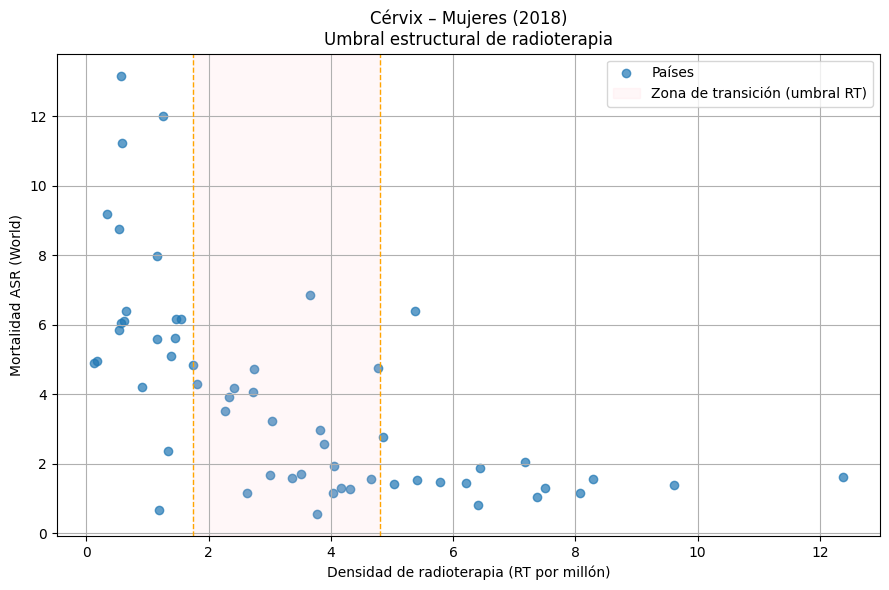

In [74]:
import matplotlib.pyplot as plt

# Filtrar datos (ejemplo: Cérvix, Mujeres, 2018)
df_plot = df_model[
    (df_model["Cancer_label"] == "Cervix") &
    (df_model["Sex"] == "Female") &
    (df_model["Year"] == 2018)
]

plt.figure(figsize=(9, 6))

# Scatter
plt.scatter(
    df_plot["RT_m"],
    df_plot["ASR_World"],
    alpha=0.7,
    label="Países"
)

# Bandas WOE
plt.axvspan(
     1.74, 4.80,
     color="pink",
     label="Zona de transición (umbral RT)",
     alpha=0.12
 )

# Líneas verticales de referencia
plt.axvline(1.74, color="orange", linestyle="--", linewidth=1)
plt.axvline(4.8, color="orange", linestyle="--", linewidth=1)

plt.xlabel("Densidad de radioterapia (RT por millón)")
plt.ylabel("Mortalidad ASR (World)")
plt.title("Cérvix – Mujeres (2018)\nUmbral estructural de radioterapia")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

El salto ocurre cuando un país pasa de no poder tratar adecuadamente a la mayoría de los casos a poder hacerlo. Eso sucede alrededor de 2–5 equipos por millón, y a partir de ahí la mortalidad deja de responder de forma fuerte a más equipos.

El análisis de los bins WOE muestra un efecto umbral en torno a 2–5 equipos de radioterapia por millón de habitantes. Por debajo de este rango, la mortalidad es elevada y altamente variable, mientras que al superarlo se observa una reducción abrupta del riesgo. Incrementos adicionales en contextos ya bien dotados no producen descensos proporcionales, lo que sugiere un efecto de saturación y explica la relación no lineal capturada por el modelo.

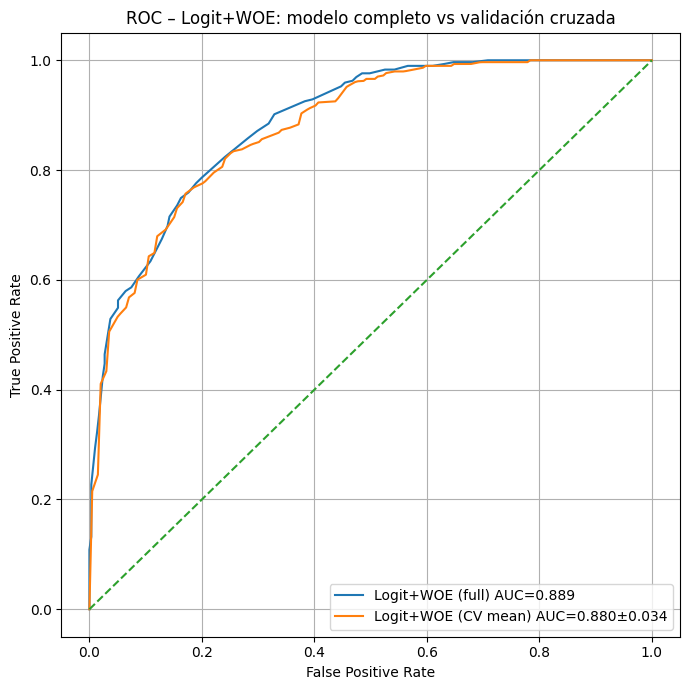

In [76]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_curve, roc_auc_score
import statsmodels.api as sm
import patsy

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --- Matriz de diseño desde fórmula ---
formula_rhs = model.model.formula.split('~')[1].strip()
X = patsy.dmatrix(formula_rhs, data=df_model, return_type='dataframe')
X = X.drop(columns='Intercept', errors='ignore')
y = df_model["High_Mortality"].astype(int)

# --- ROC del modelo "full" (entrenado con todo) ---
y_prob_full = model.predict(df_model)
fpr_full, tpr_full, _ = roc_curve(y, y_prob_full)
auc_full = roc_auc_score(y, y_prob_full)

# --- ROC en CV: acumulamos curvas ---
tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 200)

for train_idx, test_idx in skf.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    m = sm.Logit(y_train, sm.add_constant(X_train)).fit(disp=0)
    y_prob = m.predict(sm.add_constant(X_test))

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    aucs.append(roc_auc_score(y_test, y_prob))

    # interpolar TPR a la rejilla común de FPR
    tpr_interp = np.interp(mean_fpr, fpr, tpr)
    tpr_interp[0] = 0.0
    tprs.append(tpr_interp)

# Promedios
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = np.mean(aucs)
std_auc = np.std(aucs)

# --- Plot ---
plt.figure(figsize=(7, 7))
plt.plot(fpr_full, tpr_full, label=f"Logit+WOE (full) AUC={auc_full:.3f}")
plt.plot(mean_fpr, mean_tpr, label=f"Logit+WOE (CV mean) AUC={mean_auc:.3f}±{std_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC – Logit+WOE: modelo completo vs validación cruzada")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



In [77]:
from sklearn.model_selection import StratifiedKFold
import numpy as np
import statsmodels.api as sm
import patsy # Import patsy for dmatrix

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
aucs = []

# Extract the right-hand side of the formula from the previously fitted model
formula_rhs = model.model.formula.split('~')[1].strip()

# Use patsy.dmatrix to create the design matrix X from the formula and df_model
# patsy.dmatrix by default adds an 'Intercept' column. We will remove it here
# because sm.add_constant will add it inside the loop for each fold's X_train and X_test.
X = patsy.dmatrix(formula_rhs, data=df_model, return_type='dataframe')
X = X.drop(columns='Intercept', errors='ignore')

y = df_model["High_Mortality"]

for train_index, test_index in skf.split(X, y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Fit the model on the training data, adding a constant
    m = sm.Logit(y_train, sm.add_constant(X_train)).fit(disp=0)

    # Predict probabilities on the test data, adding a constant
    y_prob_test = m.predict(sm.add_constant(X_test))

    aucs.append(roc_auc_score(y_test, y_prob_test))

mean_auc = np.mean(aucs)
std_auc = np.std(aucs)

print(f"Mean AUC: {mean_auc:.3f}, Std Dev AUC: {std_auc:.3f}")

Mean AUC: 0.880, Std Dev AUC: 0.034


RANDOM FOREST

In [78]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

features = [
    "RT_m",
    "GDP_per_capita",
    "Sex",
    "Cancer_label",
    "Period"
]

df_rf = df_model[features + ["High_Mortality"]].dropna().copy()

# One-hot encoding
df_rf = pd.get_dummies(df_rf, drop_first=True)

X = df_rf.drop(columns="High_Mortality")
y = df_rf["High_Mortality"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


In [79]:
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=6,
    min_samples_leaf=10,
    random_state=42
)

rf.fit(X_train, y_train)


RandomForestClassifier(max_depth=6, min_samples_leaf=10, n_estimators=500,
                       random_state=42)

In [80]:
from sklearn.metrics import roc_auc_score

y_pred = rf.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_pred)

print(f"AUC Random Forest: {auc:.3f}")


AUC Random Forest: 0.927


In [81]:
importances = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importances.head(10)


,0
Cancer_label_Cervix,0.349189
GDP_per_capita,0.204084
RT_m,0.181362
Sex_Male,0.122799
Cancer_label_Lung,0.088325
Cancer_label_Prostate,0.041467
Period_2018,0.012773


El análisis mediante Random Forest confirma la relevancia de las variables estructurales identificadas en el modelo interpretable. El tipo de cáncer, el contexto socioeconómico y la densidad de equipos de radioterapia emergen como los principales predictores de mortalidad, mientras que el periodo temporal tiene una contribución marginal. Esta consistencia refuerza la robustez de los resultados obtenidos.

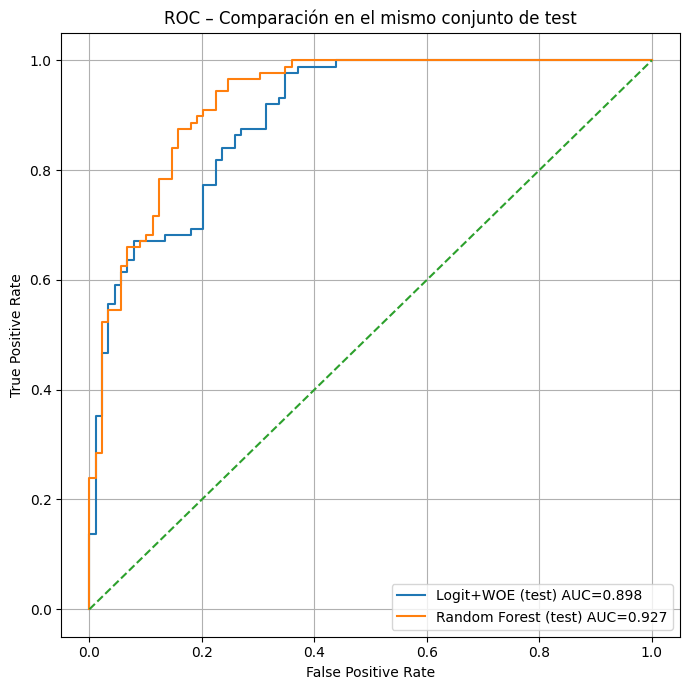

In [83]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Convert boolean columns to numeric (float) explicitly
X_train_numeric = X_train.astype(float)
X_test_numeric = X_test.astype(float)

# Logit entrenado en TRAIN y evaluado en TEST
m = sm.Logit(y_train, sm.add_constant(X_train_numeric)).fit(disp=0)
y_prob_logit_test = m.predict(sm.add_constant(X_test_numeric))

fpr_l, tpr_l, _ = roc_curve(y_test, y_prob_logit_test)
auc_l = roc_auc_score(y_test, y_prob_logit_test)

# RF en TEST
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred)
auc_rf = roc_auc_score(y_test, y_pred)

plt.figure(figsize=(7,7))
plt.plot(fpr_l, tpr_l, label=f"Logit+WOE (test) AUC={auc_l:.3f}")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (test) AUC={auc_rf:.3f}")
plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC – Comparación en el mismo conjunto de test")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

cOMPARACION DE MODELOS

Métricas de evaluación del modelo

La evaluación del rendimiento de los modelos predictivos se realizó utilizando la curva ROC (Receiver Operating Characteristic) y el área bajo dicha curva (AUC), métrica que cuantifica la capacidad discriminativa del modelo para asignar mayores probabilidades de alta mortalidad a los países efectivamente clasificados en ese grupo, independientemente del umbral de decisión utilizado. Esta elección es especialmente adecuada en el contexto del presente estudio, donde la variable objetivo presenta un cierto desbalance entre clases y no existe un umbral operativo natural para la clasificación binaria. Por este motivo, métricas dependientes del umbral, como el accuracy, no se consideran informativas ni apropiadas para los objetivos del análisis. La AUC permite una comparación robusta entre modelos y constituye el criterio principal de evaluación tanto para el modelo logístico basado en WOE como para el modelo de Random Forest, facilitando una valoración consistente de su capacidad predictiva y comparativa.

La disponibilidad de equipos de braquiterapia, muy utilizado en cáncer de cervix, muestra una mejoria/disminución en el índice de mortalidad a medida que aumenta la cantidad de equipos. En paises con menos equipos, mayor es la mortalidad, sin embargo, no posee una significancia concluyente, por lo tanto, no poddemos rechazar H0 la no relación.
Presenta además mucha dispersión vertical.

Esto no es una prueba causal, pero si una señal temporal coherente.

Al pasar de 0 a 1 equipo/millón se asocia a una reducción de la mortalidad bastante significativa, sin embargo, al pasar al doble de equipos, se aplana el efecto, esto podría deberse a pocos rendimientos de la infraestrucura sanitaria.

La infraestructura radioterapica es una variable explicativa poderosa para utilizar durante este trabajo, ahora se buscará cuantos equipos de radioterapia en total hay y si es significativo considerar todos o solamente los más utilizados como la braquiterapia y aceleradores lineales (Linac).

Para ejemplos como el cancer y pulmon y los aceleradores lineales, no existe esa correlación tan evidente, por eso, en este estudio, se analizarán distintos tipos de cancer y varios equipos de radioterapia, así como el PIB per cápita.

In [ ]:
!pip -q install shap


## Variable objetivo: mortalidad en ASR(World)

La mortalidad en ASR(World) nos indica la tasa de mortalidad ajustada por edad que resultaría si la población de cada país tuviera la misma estructura de edad que una población estándar mundial.

## Variables Predictoras o explicativas

Como variables predictoras se consideran tanto factores económicos como de infraestructura sanitaria. En particular, se utiliza el PIB per cápita como indicador del nivel de desarrollo económico y de la capacidad general del sistema sanitario. Asimismo, se incluyen los distintos tipos de equipos de radioterapia disponibles por millón de habitantes, con el objetivo de capturar la disponibilidad y capacidad terapéutica en cada país.

Adicionalmente, el análisis se estratifica por tipo de cáncer y sexo, dado que la incidencia, la mortalidad y la respuesta al tratamiento presentan diferencias relevantes según estas dimensiones. Esta estratificación permite evaluar de forma más precisa la heterogeneidad en los patrones de mortalidad y en la relación entre infraestructura radioterápica y resultados en salud.

## Selección temporal y enfoque de modelización

A partir del análisis exploratorio y del proceso de depuración de los datos, se identificaron limitaciones relevantes tanto en la cobertura temporal como en la naturaleza de las relaciones entre las variables de interés. En particular, los análisis de disponibilidad mostraron que, a partir de 2017, los datos de incidencia presentan una cobertura insuficiente y heterogénea entre países y tipos de cáncer, mientras que la mortalidad mantiene una cobertura amplia y consistente. Por este motivo, la mortalidad estandarizada por edad (ASR, World) se adopta como variable objetivo principal del estudio.

Dentro del periodo disponible, el año 2022 se selecciona como año de referencia para el análisis principal, al tratarse del año más reciente con información consolidada y comparativamente homogénea en las variables epidemiológicas y de infraestructura sanitaria. Esta elección permite maximizar la representatividad del análisis y centrar el estudio en una fotografía actualizada de la relación entre mortalidad por cáncer y disponibilidad de recursos tanto terapéuticos como económicos.

Por otra parte, las representaciones gráficas y análisis exploratorios realizados evidencian que la relación entre la mortalidad y las variables explicativas —incluyendo la incidencia y la disponibilidad de equipos de radioterapia— no sigue un patrón lineal simple. En particular, se observan efectos no lineales, asimetrías y posibles rendimientos decrecientes, especialmente en los niveles bajos de infraestructura sanitaria. En este contexto, el uso de modelos lineales convencionales podría resultar restrictivo o conducir a interpretaciones parciales.

En consecuencia, se adopta un enfoque basado en Weight of Evidence (WOE) para la construcción del modelo base.

-----------------------------------------------------

Tras el análisis exploratorio y la depuración de los datos, se selecciona el año 2022 como referencia principal por su mayor cobertura y consistencia.

 Dado que las relaciones observadas entre mortalidad e infraestructuras sanitarias no presentan un comportamiento lineal, se adopta un enfoque basado en Weight of Evidence (WOE) como modelo base, que permite capturar de forma más adecuada la naturaleza no lineal de dichas relaciones.



***


# WOE

 En particular por defecto `optbinning` define el WOE de una categoría $i$ como
$$ WOE_i =  ln \left ( {Non-event_i \over Non-event_{total}} \over {Event_i \over Event_{total}}    \right ) $$

¿bajo que criterio utilizaremos IV? que valor?
Por talmotivo utilizaremos como criterio de selección exclusivamente IV<0.002

Podemos extraer el IV y el índice de Gini a partir de la tabla

# Estimación del Modelo

Ahora podemos calcular la tarjeta de puntuación. En los apuntes de clase definimos tanto los WOE, como los Odd ratio como la probabilidad de `evento` respecto al `no-evento` (malos clientes o impago=1 respecto a los buenos clientes o impago=0):

$$ odd = {{P}\over {(1-P)}} ~~ {,~~  siendo} ~~  {P=Prob(impago=1)} $$

 Y la fórmula para obtener la puntuación o los score debe ser una relación negativa con los odd ratio: cuanto mayor la probabilidad de impago (en relación a la de no impago), menor puntuación ha de tener:

 $$ score {= offset - Factor}~·~{ln(odds)}$$

Para pasar de Probabiliddes de impago a Puntuaciones, habrá que establecer tanto el valor de `offset` como el de `Factor`. Esto se hace de manera arbitraria dependiendo de cada institución financiera.

En general, para determinar estos dos valores es necesario establecer la pendiente de la recta y un punto de la misma.

En cuanto a la pendiente, cuanto más plana sea la pendiente, menor variabilidad tendrán los valores de puntuación de crédito que se alcancen, y al revés, cuanto mayor pendiente más diferencias en la puntuación final. Yo voy a utilizar un apendiente (arbitraria) estableciendo de forma arbitraria cada cuantos puntos de score (**pdo_0**) se dobla el odd ratio: $ score - pdo_0 = {offset -Factor}~ ·{ln(2*odds)}$.

 En cuanto al punto de la recta (arbitrario), puede hacerse estableciento (de manera arbitraria) la puntuación o score considerada como de sobresaliente(**scorecard_points**) y el odd ratio que debería tener ese cliente de *sobresaliente* (**odds_0**)

 Así habría que establecer tres parámetros para transformar probabilidades de impago a puntuaciones, por ejemplo:   

* **pdo_0** =40  (esto es que cada 40 puntos de calidad creditica se dobla el odd-ratio))
* **scorecard_points** =600  (alguien con calidad crediticia muy buena, de sobresaliente, sacaría 600 puntos)
* **odds_0** =1/50  (odd ratio que se considera de sobresaliente)

La librería `optBinning` [librería OptBinning](http://gnpalencia.org/optbinning/), en realidad utiliza el módulo de `credit scoring` de `SAS-miner` como inspiración, y por eso define al revés tanto los WOE como los odd ratio, es decir `no-evento` en relación a `evento` (clientes buenos respecto a los malos, o no-impago respecto a impago, impago=0 respecto a impago=1).
$$ odd^B = {{(1-P)}\over {P}} ~~ {,~~  siendo} ~~  {P=Prob(impago=1)} $$

Esto implica que la ecuación que transforma las probabilidades de impago en scores utilizando esta *odds<sup>B</sup>* debe tener pendiente positiva (cuanto mejor *odd<sup>B</sup>* mejor calidad crediticia tiene el cliente)

 $$ score= {offset + Factor} ~·~ {ln(odds^B)}$$

 Nótese que ahora habrá que establecer de nuevo los puntos de score que doblan el odd ratio (**pdo_0**), y también la puntuación o score considerada como de sobresaliente(**scorecard_points**) y el odd ratio que debería tener ese cliente de *sobresaliente* **odds_0 <sup>*B*</sup>**, con **odds_0 <sup>*B*</sup>** **= 1/odds_0**.

 Así para estimar la puntuación crediticia con `optBinning` hay que establecer tres parámetros para transformar probabilidades de impago a puntuaciones, por ejemplo:   

* **pdo_0** =40
* **scorecard_points** =600
* **odds_0 <sup>*B*</sup>** = 50  (equivalente a **odds_0** =1/50 )


